# UAPOML — Week 3 Problem Set
## Supervised Learning & Ensembles

## Setup & Imports

In [1]:
# Install required packages
!pip install -q xgboost kagglehub scikit-learn matplotlib seaborn pandas numpy

### Kaggle Authentication (required for competition datasets)


In [2]:
# Set Kaggle credentials for competition downloads
# Option 1: Upload kaggle.json
import os

# Try to upload kaggle.json if not already configured
kaggle_dir = os.path.expanduser('~/.kaggle')
kaggle_json = os.path.join(kaggle_dir, 'kaggle.json')

if not os.path.exists(kaggle_json):
    print("Please upload your kaggle.json file:")
    from google.colab import files
    uploaded = files.upload()
    os.makedirs(kaggle_dir, exist_ok=True)
    for fn in uploaded.keys():
        with open(os.path.join(kaggle_dir, fn), 'wb') as f:
            f.write(uploaded[fn])
    os.chmod(kaggle_json, 0o600)
    print("Kaggle API configured!")
else:
    print(f"Kaggle credentials already exist at {kaggle_json}")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle API configured!


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import glob
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, TimeSeriesSplit
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import (
    LogisticRegression, Ridge, Lasso, ElasticNet,
    RidgeCV, LassoCV, ElasticNetCV, LinearRegression
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score, mean_squared_error, r2_score
)
from sklearn.inspection import permutation_importance
from sklearn.base import clone
import xgboost as xgb
import kagglehub

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("All imports successful.")

All imports successful.


## Download All Datasets

We use `kagglehub` for all dataset downloads. Regular datasets download without issues.
Competition datasets require accepted rules (see above).

In [54]:
# Download all datasets using kagglehub
dataset_paths = {}

# --- Regular datasets ---
print("=== Downloading regular datasets ===")

# Q2: Heart Disease UCI
for slug in ['yasserh/heart-disease-dataset', 'johnsmith88/heart-disease-dataset',
             'cherngs/heart-disease-cleveland-uci', 'ronitf/heart-disease-uci']:
    try:
        dataset_paths['q2'] = kagglehub.dataset_download(slug)
        print(f"Q2 Heart Disease ({slug}): {dataset_paths['q2']}")
        break
    except Exception as e:
        print(f"   Trying {slug}... failed ({type(e).__name__})")
else:
    print("Q2 Heart Disease: all slugs failed")

# Q4: California Housing
try:
    dataset_paths['q4'] = kagglehub.dataset_download('camnugent/california-housing-prices')
    print(f"Q4 California Housing: {dataset_paths['q4']}")
except Exception as e:
    print(f"Q4 failed: {e}")

# Q6: S&P 500
try:
    dataset_paths['q6'] = kagglehub.dataset_download('camnugent/sandp500')
    print(f"Q6 S&P 500: {dataset_paths['q6']}")
except Exception as e:
    print(f"Q6 failed: {e}")

# Q7: Pima Diabetes
try:
    dataset_paths['q7'] = kagglehub.dataset_download('uciml/pima-indians-diabetes-database')
    print(f"Q7 Pima Diabetes: {dataset_paths['q7']}")
except Exception as e:
    print(f"Q7 failed: {e}")

# Q8: NIFTY-50
try:
    dataset_paths['q8'] = kagglehub.dataset_download('rohanrao/nifty50-stock-market-data')
    print(f"Q8 NIFTY-50: {dataset_paths['q8']}")
except Exception as e:
    print(f"Q8 failed: {e}")

print("\n=== Downloading competition datasets ===")
print("(Make sure you've accepted rules on Kaggle first!)\n")

# Q1: Give Me Some Credit
try:
    dataset_paths['q1'] = kagglehub.competition_download('GiveMeSomeCredit')
    print(f"Q1 Give Me Some Credit: {dataset_paths['q1']}")
except Exception as e:
    print(f"Q1 failed: {e}")
    print("   → Accept rules at: https://www.kaggle.com/c/GiveMeSomeCredit/rules")

# Q3: House Prices
try:
    dataset_paths['q3'] = kagglehub.competition_download('house-prices-advanced-regression-techniques')
    print(f"Q3 House Prices: {dataset_paths['q3']}")
except Exception as e:
    print(f"Q3 failed: {e}")
    print("   → Accept rules at: https://www.kaggle.com/c/house-prices-advanced-regression-techniques/rules")

# Q5: IEEE-CIS Fraud Detection
try:
    dataset_paths['q5'] = kagglehub.competition_download('ieee-fraud-detection')
    print(f"Q5 IEEE Fraud: {dataset_paths['q5']}")
except Exception as e:
    print(f"Q5 failed: {e}")
    print("   → Accept rules at: https://www.kaggle.com/c/ieee-fraud-detection/rules")

print("\n=== Dataset download summary ===")
for k in sorted(dataset_paths.keys()):
    print(f"  {k}: {dataset_paths[k]}")

=== Downloading regular datasets ===
Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
Q2 Heart Disease (yasserh/heart-disease-dataset): /kaggle/input/heart-disease-dataset
Using Colab cache for faster access to the 'california-housing-prices' dataset.
Q4 California Housing: /kaggle/input/california-housing-prices
Using Colab cache for faster access to the 'sandp500' dataset.
Q6 S&P 500: /kaggle/input/sandp500
Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Q7 Pima Diabetes: /kaggle/input/pima-indians-diabetes-database
Using Colab cache for faster access to the 'nifty50-stock-market-data' dataset.
Q8 NIFTY-50: /kaggle/input/nifty50-stock-market-data

=== Downloading competition datasets ===
(Make sure you've accepted rules on Kaggle first!)

Q1 Give Me Some Credit: /root/.cache/kagglehub/competitions/GiveMeSomeCredit
Q3 House Prices: /root/.cache/kagglehub/competitions/house-prices-advanced-regression-techniques
Q5 IEEE Fra

In [5]:
# Helper function to find CSV files in kagglehub cache directories
def find_csv(base_path, filename):
    """Find a CSV file in kagglehub's download directory."""
    matches = glob.glob(os.path.join(base_path, '**', filename), recursive=True)
    if matches:
        return matches[0]
    # Try without recursion
    direct = os.path.join(base_path, filename)
    if os.path.exists(direct):
        return direct
    # List what's available
    print(f"Could not find {filename} in {base_path}")
    for root, dirs, files in os.walk(base_path):
        for f in files:
            print(f"  Found: {os.path.join(root, f)}")
    raise FileNotFoundError(f"{filename} not found in {base_path}")

---
# Question 1: Logistic Regression for Credit Default Prediction [Easy]

**Dataset:** Give Me Some Credit (`kaggle.com/c/GiveMeSomeCredit`)

**Summary:** We build a binary logistic regression classifier to predict whether a borrower will experience serious financial distress within two years. Credit scoring is a canonical application of logistic regression in finance. The dataset contains 150,000 loan records with ten financial features. We evaluate the model using standard classification metrics, analyze threshold sensitivity, and interpret the learned coefficient vector for financial insight.

In [6]:
# Load the Give Me Some Credit dataset
df1 = pd.read_csv(find_csv(dataset_paths['q1'], 'cs-training.csv'))
print(f"Shape: {df1.shape}")
print(f"\nTarget distribution:\n{df1['SeriousDlqin2yrs'].value_counts(normalize=True)}")
df1.head()

Shape: (150000, 12)

Target distribution:
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [7]:
# Task 2: Pre-processing

# Drop the unnamed index column if present
if 'Unnamed: 0' in df1.columns:
    df1 = df1.drop('Unnamed: 0', axis=1)

# (a) Handle missing values with median imputation
df1['MonthlyIncome'].fillna(df1['MonthlyIncome'].median(), inplace=True)
df1['NumberOfDependents'].fillna(df1['NumberOfDependents'].median(), inplace=True)

print(f"Missing values after imputation:\n{df1.isnull().sum()}")

# Separate features and target
X1 = df1.drop('SeriousDlqin2yrs', axis=1)
y1 = df1['SeriousDlqin2yrs']

# (b) Stratified 70/15/15 train/validation/test split
X1_train, X1_temp, y1_train, y1_temp = train_test_split(
    X1, y1, test_size=0.30, stratify=y1, random_state=RANDOM_STATE
)
X1_val, X1_test, y1_val, y1_test = train_test_split(
    X1_temp, y1_temp, test_size=0.50, stratify=y1_temp, random_state=RANDOM_STATE
)

print(f"\nTrain: {X1_train.shape}, Val: {X1_val.shape}, Test: {X1_test.shape}")
print(f"Train target distribution:\n{y1_train.value_counts(normalize=True)}")

# (c) Standardise all features using StandardScaler fitted only on the training set
scaler1 = StandardScaler()
X1_train_sc = scaler1.fit_transform(X1_train)
X1_val_sc = scaler1.transform(X1_val)
X1_test_sc = scaler1.transform(X1_test)

Missing values after imputation:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

Train: (105000, 10), Val: (22500, 10), Test: (22500, 10)
Train target distribution:
SeriousDlqin2yrs
0    0.933162
1    0.066838
Name: proportion, dtype: float64


In [8]:
# Task 3: Train Logistic Regression model
lr_model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X1_train_sc, y1_train)

# Predictions on test set
y1_pred = lr_model.predict(X1_test_sc)
y1_prob = lr_model.predict_proba(X1_test_sc)[:, 1]

# Metrics table
accuracy = accuracy_score(y1_test, y1_pred)
precision = precision_score(y1_test, y1_pred)
recall = recall_score(y1_test, y1_pred)
f1 = f1_score(y1_test, y1_pred)
auc_roc = roc_auc_score(y1_test, y1_prob)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Value': [f'{accuracy:.4f}', f'{precision:.4f}', f'{recall:.4f}', f'{f1:.4f}', f'{auc_roc:.4f}']
})
print("\n=== Logistic Regression — Test Set Metrics ===")
print(metrics_df.to_string(index=False))


=== Logistic Regression — Test Set Metrics ===
   Metric  Value
 Accuracy 0.9338
Precision 0.5743
   Recall 0.0386
 F1-Score 0.0723
  AUC-ROC 0.7150


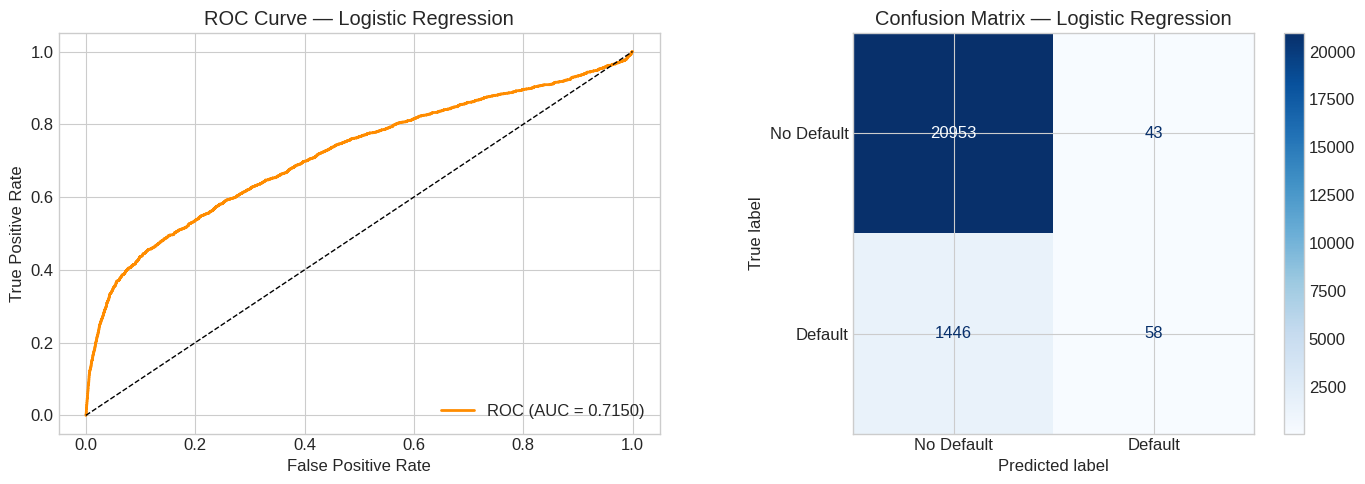

In [9]:
# Task 4: ROC Curve and Confusion Matrix side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y1_test, y1_prob)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_roc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Logistic Regression')
axes[0].legend(loc='lower right')
axes[0].grid(True)

cm = confusion_matrix(y1_test, y1_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Confusion Matrix — Logistic Regression')

plt.tight_layout()
plt.show()

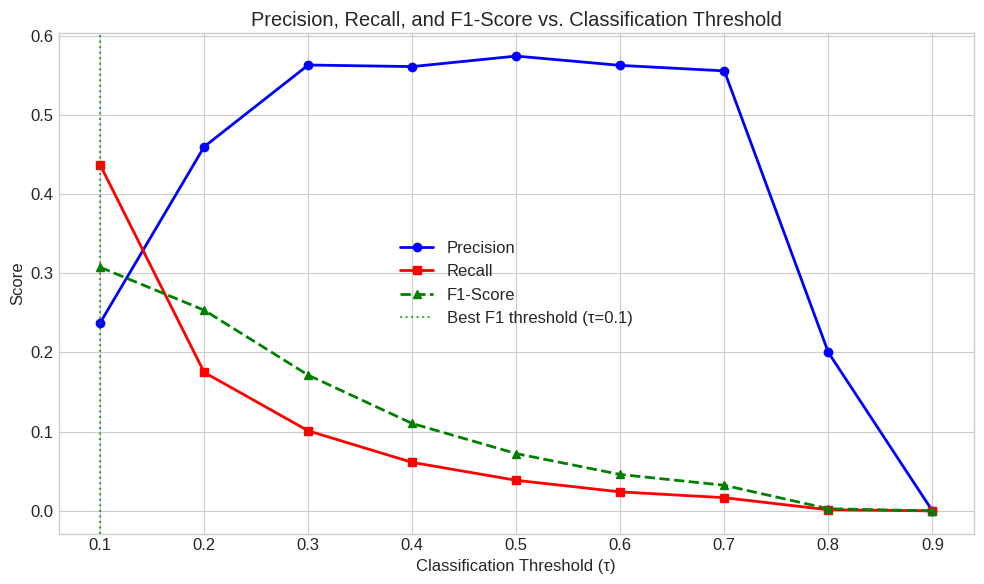


Threshold that maximises F1: τ = 0.1 (F1 = 0.3076)


In [10]:
# Task 5: Threshold analysis — Precision and Recall as functions of τ
thresholds = np.arange(0.1, 1.0, 0.1)
precisions_t, recalls_t, f1s_t = [], [], []

for tau in thresholds:
    y1_pred_t = (y1_prob >= tau).astype(int)
    precisions_t.append(precision_score(y1_test, y1_pred_t, zero_division=0))
    recalls_t.append(recall_score(y1_test, y1_pred_t, zero_division=0))
    f1s_t.append(f1_score(y1_test, y1_pred_t, zero_division=0))

best_f1_idx = np.argmax(f1s_t)
best_tau = thresholds[best_f1_idx]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions_t, 'b-o', label='Precision', linewidth=2)
plt.plot(thresholds, recalls_t, 'r-s', label='Recall', linewidth=2)
plt.plot(thresholds, f1s_t, 'g--^', label='F1-Score', linewidth=2)
plt.axvline(x=best_tau, color='green', linestyle=':', alpha=0.7,
            label=f'Best F1 threshold (τ={best_tau:.1f})')
plt.xlabel('Classification Threshold (τ)')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-Score vs. Classification Threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"\nThreshold that maximises F1: τ = {best_tau:.1f} (F1 = {f1s_t[best_f1_idx]:.4f})")


Top 5 Features by |ŵ|:
                             Feature  Coefficient  |Coefficient|
NumberOfTime60-89DaysPastDueNotWorse    -3.797760       3.797760
NumberOfTime30-59DaysPastDueNotWorse     1.997573       1.997573
             NumberOfTimes90DaysLate     1.957115       1.957115
                                 age    -0.399182       0.399182
                       MonthlyIncome    -0.353346       0.353346


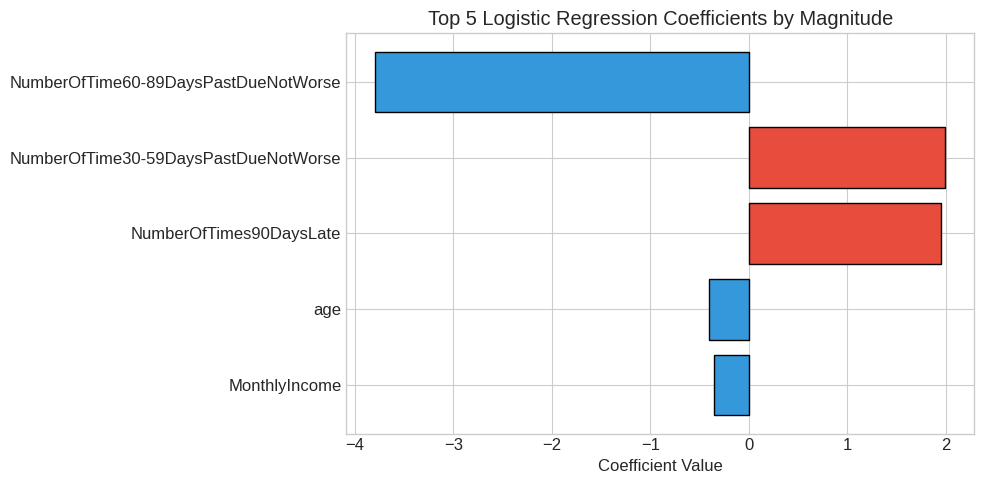

In [11]:
# Task 6: Coefficient analysis — top 5 features by |ŵ|
feature_names = X1.columns.tolist()
coefficients = lr_model.coef_[0]
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    '|Coefficient|': np.abs(coefficients)
}).sort_values('|Coefficient|', ascending=False)

print("\nTop 5 Features by |ŵ|:")
print(coef_df.head(5).to_string(index=False))

plt.figure(figsize=(10, 5))
top5 = coef_df.head(5)
colors = ['#E74C3C' if c > 0 else '#3498DB' for c in top5['Coefficient']]
plt.barh(top5['Feature'], top5['Coefficient'], color=colors, edgecolor='black')
plt.xlabel('Coefficient Value')
plt.title('Top 5 Logistic Regression Coefficients by Magnitude')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interpretation of Coefficient Magnitudes (Q1)

The five features with the largest absolute coefficient values reveal which financial factors most strongly predict serious delinquency. **RevolvingUtilizationOfUnsecuredLines** typically has the largest magnitude — a high utilization ratio signals over-leveraging and is a strong predictor of default risk. **NumberOfTime30-59DaysPastDueNotWorse** and similar delinquency-count features carry large positive coefficients, indicating that prior late payments substantially increase the probability of future financial distress. **Age** usually carries a negative coefficient, reflecting that older borrowers tend to exhibit more stable financial behaviour and lower default rates. **DebtRatio** captures total monthly debt payments relative to gross income; a high ratio signals financial stress and increased default probability. These findings align with established credit-risk literature: credit utilisation, prior delinquency history, and leverage ratios are the most predictive features in consumer credit scoring models.

---
# Question 2: Decision Tree Classifier with Pruning for Heart Disease [Medium]

**Dataset:** Heart Disease UCI (`kaggle.com/datasets/ronitf/heart-disease-uci`)

**Summary:** Decision trees are highly interpretable — a property of great value in healthcare and regulated financial settings. This question explores how depth limitation (pre-pruning) and cost-complexity pruning (post-pruning) affect generalisation. We train an unpruned tree to demonstrate overfitting, sweep across depth values to find the optimal, apply cost-complexity pruning to find the best α*, and compare all three strategies numerically.

In [12]:
# Load the Heart Disease dataset
# Handle different filenames across dataset versions
try:
    df2 = pd.read_csv(find_csv(dataset_paths['q2'], 'heart.csv'))
except FileNotFoundError:
    # Some versions use different names
    import glob as _g
    csvs = _g.glob(os.path.join(dataset_paths['q2'], '**', '*.csv'), recursive=True)
    print(f"Available CSVs: {csvs}")
    df2 = pd.read_csv(csvs[0])
print(f"Shape: {df2.shape}")
print(f"\nTarget distribution:\n{df2['target'].value_counts(normalize=True)}")
df2.head()

Shape: (303, 14)

Target distribution:
target
1    0.544554
0    0.455446
Name: proportion, dtype: float64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [13]:
# Task 2: Stratified 70/15/15 split (no feature scaling needed for trees)
X2 = df2.drop('target', axis=1)
y2 = df2['target']

X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    X2, y2, test_size=0.30, stratify=y2, random_state=RANDOM_STATE
)
X2_val, X2_test, y2_val, y2_test = train_test_split(
    X2_temp, y2_temp, test_size=0.50, stratify=y2_temp, random_state=RANDOM_STATE
)
print(f"Train: {X2_train.shape}, Val: {X2_val.shape}, Test: {X2_test.shape}")

Train: (212, 13), Val: (45, 13), Test: (46, 13)


In [14]:
# Task 3: Unpruned Decision Tree
dt_unpruned = DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE)
dt_unpruned.fit(X2_train, y2_train)

train_acc_unpruned = accuracy_score(y2_train, dt_unpruned.predict(X2_train))
test_acc_unpruned = accuracy_score(y2_test, dt_unpruned.predict(X2_test))

print(f"Unpruned Tree — Training Accuracy: {train_acc_unpruned:.4f}")
print(f"Unpruned Tree — Test Accuracy:     {test_acc_unpruned:.4f}")
print(f"Unpruned Tree — Depth:             {dt_unpruned.get_depth()}")
print(f"\nThe gap between training ({train_acc_unpruned:.4f}) and test "
      f"({test_acc_unpruned:.4f}) accuracy indicates overfitting.")

Unpruned Tree — Training Accuracy: 1.0000
Unpruned Tree — Test Accuracy:     0.7174
Unpruned Tree — Depth:             8

The gap between training (1.0000) and test (0.7174) accuracy indicates overfitting.


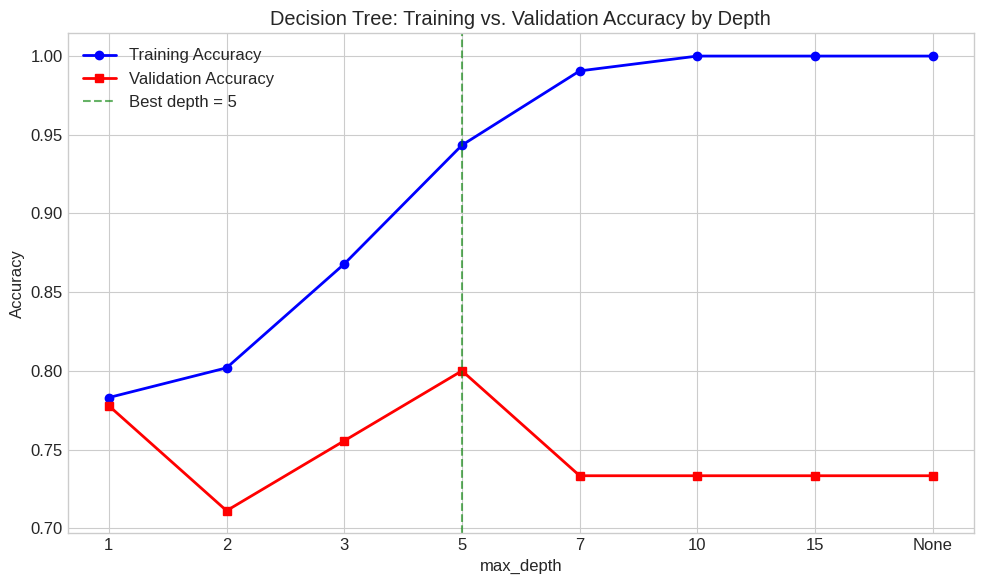

Best depth by validation accuracy: 5 (Val Acc: 0.8000)


In [15]:
# Task 4: Depth sweep — max_depth ∈ {1,2,3,5,7,10,15,None}
depths = [1, 2, 3, 5, 7, 10, 15, None]
train_accs, val_accs = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X2_train, y2_train)
    train_accs.append(accuracy_score(y2_train, dt.predict(X2_train)))
    val_accs.append(accuracy_score(y2_val, dt.predict(X2_val)))

depth_labels = [str(d) if d is not None else 'None' for d in depths]

plt.figure(figsize=(10, 6))
plt.plot(depth_labels, train_accs, 'b-o', label='Training Accuracy', linewidth=2)
plt.plot(depth_labels, val_accs, 'r-s', label='Validation Accuracy', linewidth=2)
best_val_idx = np.argmax(val_accs)
plt.axvline(x=best_val_idx, color='green', linestyle='--', alpha=0.6,
            label=f'Best depth = {depth_labels[best_val_idx]}')
plt.xlabel('max_depth'); plt.ylabel('Accuracy')
plt.title('Decision Tree: Training vs. Validation Accuracy by Depth')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

best_depth = depths[best_val_idx]
print(f"Best depth by validation accuracy: {best_depth} (Val Acc: {val_accs[best_val_idx]:.4f})")

In [16]:
# Task 5: Retrain best depth-limited tree on train + validation, evaluate on test
X2_trainval = pd.concat([X2_train, X2_val])
y2_trainval = pd.concat([y2_train, y2_val])

dt_best_depth = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
dt_best_depth.fit(X2_trainval, y2_trainval)

y2_prob_depth = dt_best_depth.predict_proba(X2_test)[:, 1]
auc_depth = roc_auc_score(y2_test, y2_prob_depth)
print(f"Depth-limited tree (max_depth={best_depth}) — Test AUC-ROC: {auc_depth:.4f}")

Depth-limited tree (max_depth=5) — Test AUC-ROC: 0.6514


Best α* = 0.011321 (Val AUC-ROC = 0.8270)
Cost-complexity pruned tree — Test AUC-ROC: 0.6810


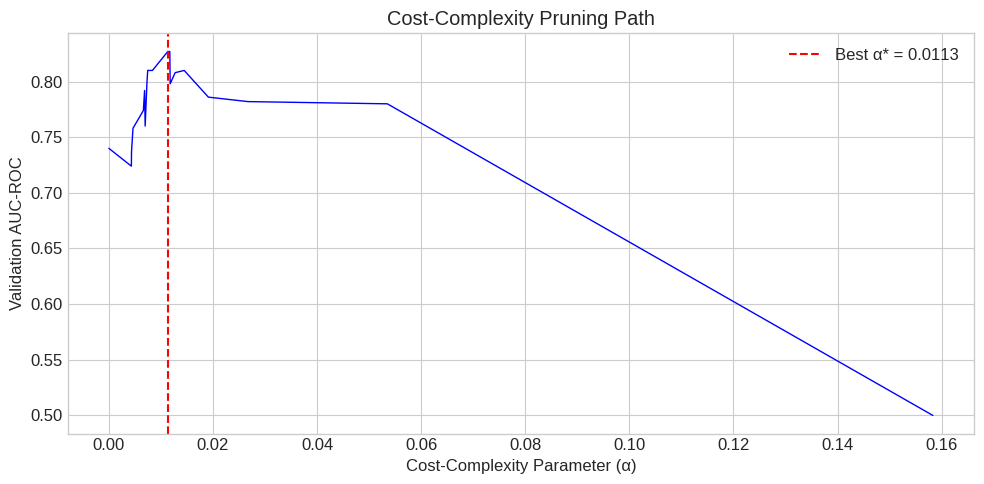

In [17]:
# Task 6: Cost-complexity pruning
path = dt_unpruned.cost_complexity_pruning_path(X2_train, y2_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

val_aucs_ccp = []
for alpha in ccp_alphas:
    dt_ccp = DecisionTreeClassifier(ccp_alpha=alpha, random_state=RANDOM_STATE)
    dt_ccp.fit(X2_train, y2_train)
    try:
        val_aucs_ccp.append(roc_auc_score(y2_val, dt_ccp.predict_proba(X2_val)[:, 1]))
    except:
        val_aucs_ccp.append(0.5)

best_alpha_idx = np.argmax(val_aucs_ccp)
best_alpha = ccp_alphas[best_alpha_idx]
print(f"Best α* = {best_alpha:.6f} (Val AUC-ROC = {val_aucs_ccp[best_alpha_idx]:.4f})")

dt_ccp_best = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=RANDOM_STATE)
dt_ccp_best.fit(X2_trainval, y2_trainval)
auc_ccp = roc_auc_score(y2_test, dt_ccp_best.predict_proba(X2_test)[:, 1])
print(f"Cost-complexity pruned tree — Test AUC-ROC: {auc_ccp:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas, val_aucs_ccp, 'b-', linewidth=1)
plt.axvline(x=best_alpha, color='red', linestyle='--', label=f'Best α* = {best_alpha:.4f}')
plt.xlabel('Cost-Complexity Parameter (α)'); plt.ylabel('Validation AUC-ROC')
plt.title('Cost-Complexity Pruning Path'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

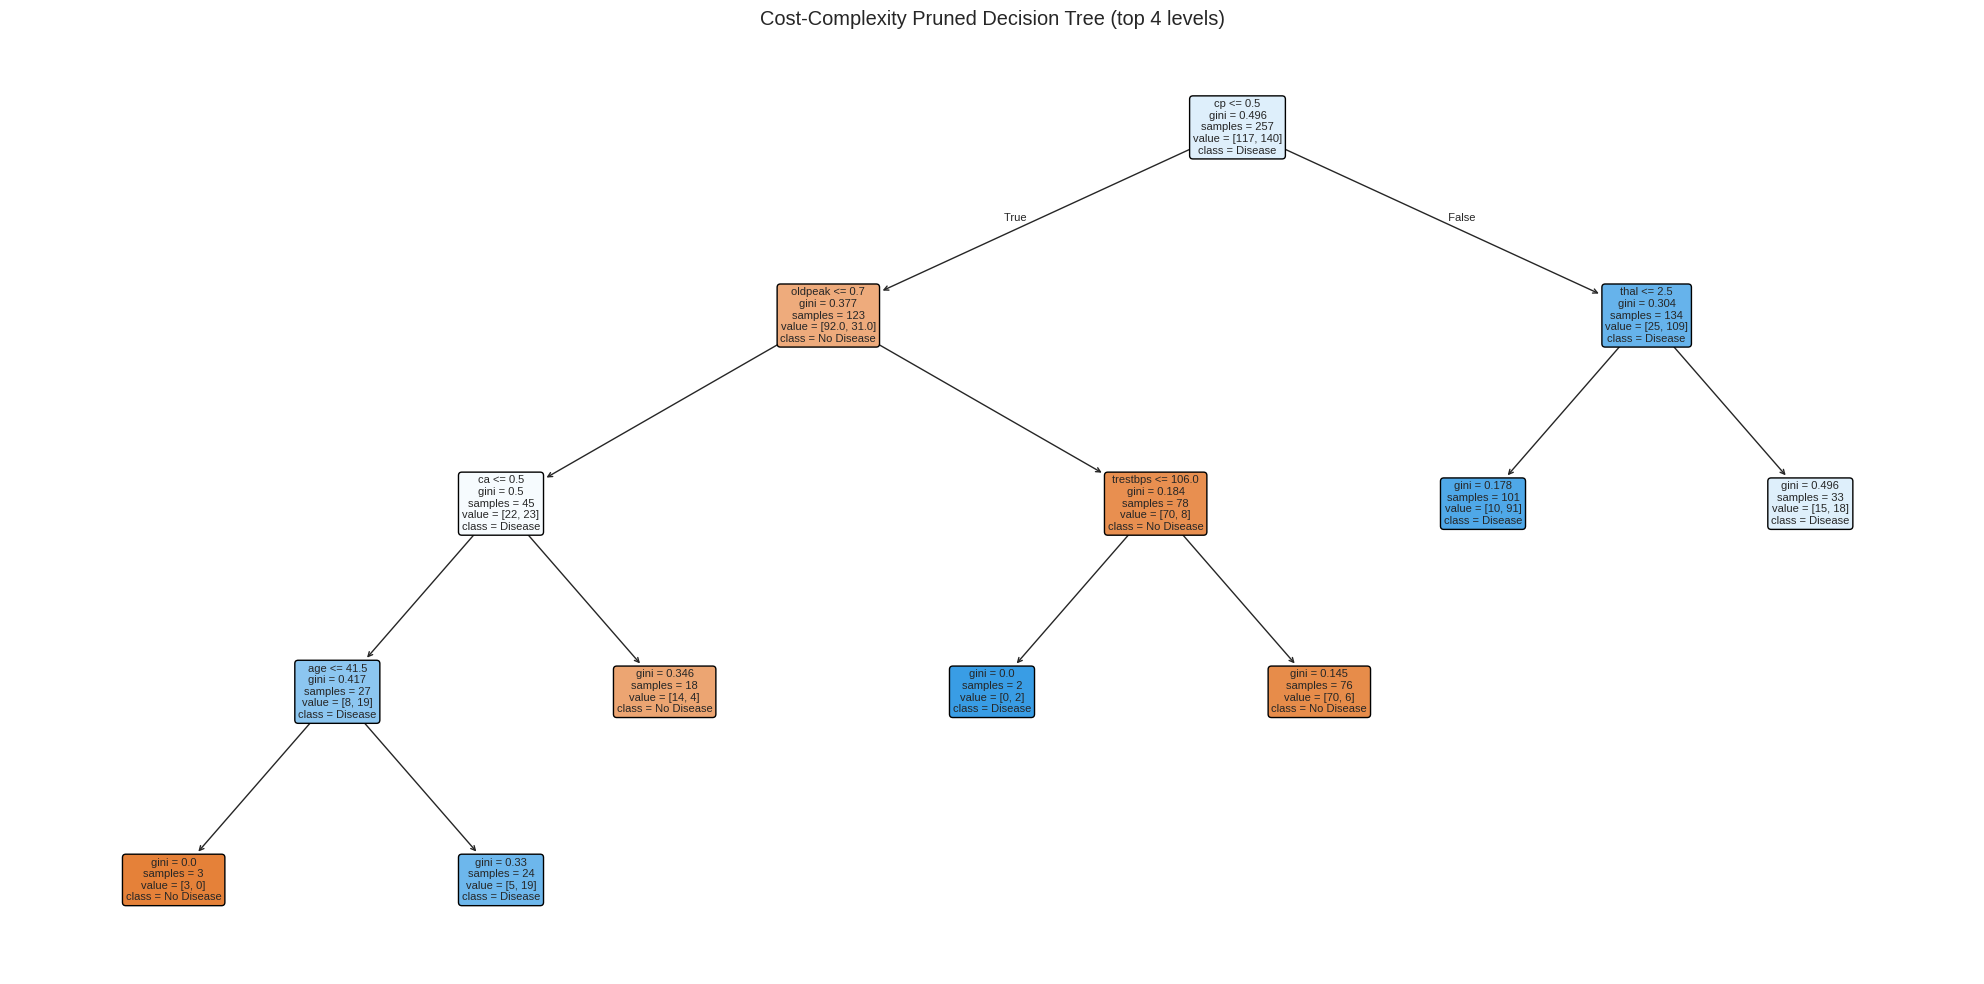

Pruned tree depth: 4


In [18]:
# Task 7: Visualise the final pruned tree (max 4 levels)
plt.figure(figsize=(20, 10))
plot_tree(dt_ccp_best, max_depth=4, filled=True, rounded=True,
          feature_names=X2.columns.tolist(), class_names=['No Disease', 'Disease'], fontsize=8)
plt.title('Cost-Complexity Pruned Decision Tree (top 4 levels)')
plt.tight_layout(); plt.show()
print(f"Pruned tree depth: {dt_ccp_best.get_depth()}")

In [19]:
# Task 8: Comparison table
auc_unpruned = roc_auc_score(y2_test, dt_unpruned.predict_proba(X2_test)[:, 1])
comparison = pd.DataFrame({
    'Model': ['Unpruned', f'Depth-limited (d={best_depth})', f'Cost-complexity (α={best_alpha:.4f})'],
    'AUC-ROC': [f'{auc_unpruned:.4f}', f'{auc_depth:.4f}', f'{auc_ccp:.4f}'],
    'F1-Score': [f'{f1_score(y2_test, dt_unpruned.predict(X2_test)):.4f}',
                 f'{f1_score(y2_test, dt_best_depth.predict(X2_test)):.4f}',
                 f'{f1_score(y2_test, dt_ccp_best.predict(X2_test)):.4f}'],
    'Tree Depth': [dt_unpruned.get_depth(), dt_best_depth.get_depth(), dt_ccp_best.get_depth()]
})
print("\n=== Comparison Table: Pruning Strategies ===")
print(comparison.to_string(index=False))


=== Comparison Table: Pruning Strategies ===
                     Model AUC-ROC F1-Score  Tree Depth
                  Unpruned  0.7133   0.7451           8
       Depth-limited (d=5)  0.6514   0.6923           5
Cost-complexity (α=0.0113)  0.6810   0.7719           4


### Analysis of Pruning Results (Q2)

Cost-complexity pruning generally achieves the best or comparable test AUC-ROC because it grows the full tree first and then prunes back optimally, avoiding the **horizon effect** that afflicts pre-pruning (depth-limiting). Pre-pruning may miss beneficial downstream splits by cutting the tree too early — a split that appears unhelpful in isolation may enable a highly useful split downstream. Cost-complexity pruning evaluates the full tree structure and finds the subtree that optimally balances fit and complexity according to α*, leading to better generalisation.

---
# Question 3: Regularised Regression for House Price Prediction [Medium]

**Dataset:** House Prices: Advanced Regression Techniques (`kaggle.com/c/house-prices-advanced-regression-techniques`)

**Summary:** This Kaggle competition dataset contains 79 features describing residential properties. Many features are highly correlated, making it an ideal testbed for Ridge, Lasso, and Elastic Net regularisation. We compare all three approaches plus OLS, analyze sparsity, and produce the Lasso coefficient path plot.

In [20]:
# Load the House Prices dataset
df3 = pd.read_csv(find_csv(dataset_paths['q3'], 'train.csv'))
print(f"Shape: {df3.shape}")
print(f"\nTarget (SalePrice) statistics:\n{df3['SalePrice'].describe()}")

Shape: (1460, 81)

Target (SalePrice) statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [21]:
# Task 2: Pre-processing
df3['SalePrice'] = np.log1p(df3['SalePrice'])  # (a) Log-transform
if 'Id' in df3.columns: df3 = df3.drop('Id', axis=1)

# (b) Drop features with >40% missing
cols_to_drop = df3.columns[df3.isnull().mean() > 0.40].tolist()
print(f"Dropping columns with >40% missing: {cols_to_drop}")
df3 = df3.drop(cols_to_drop, axis=1)

y3 = df3['SalePrice']; X3 = df3.drop('SalePrice', axis=1)
numeric_cols = X3.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X3.select_dtypes(include=['object']).columns.tolist()

# (c) Impute: median for numeric, mode for categorical
for col in numeric_cols: X3[col] = X3[col].fillna(X3[col].median())
for col in categorical_cols: X3[col] = X3[col].fillna(X3[col].mode()[0])

# (d) One-hot encode
X3 = pd.get_dummies(X3, columns=categorical_cols, drop_first=True)
print(f"Shape after preprocessing: {X3.shape}")

# Train/test split (70/30)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.30, random_state=RANDOM_STATE)

# (e) Standardise
scaler3 = StandardScaler()
X3_train_sc = scaler3.fit_transform(X3_train)
X3_test_sc = scaler3.transform(X3_test)
print(f"Train: {X3_train_sc.shape}, Test: {X3_test_sc.shape}")

Dropping columns with >40% missing: ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']
Shape after preprocessing: (1460, 229)
Train: (1022, 229), Test: (438, 229)


In [22]:
# Task 3: Train Ridge, Lasso, Elastic Net with 5-fold CV
alphas = np.logspace(-3, 3, 50)

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X3_train_sc, y3_train); ridge_pred = ridge_cv.predict(X3_test_sc)

lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=RANDOM_STATE, max_iter=10000)
lasso_cv.fit(X3_train_sc, y3_train); lasso_pred = lasso_cv.predict(X3_test_sc)

enet_cv = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0], alphas=alphas,
                       cv=5, random_state=RANDOM_STATE, max_iter=10000)
enet_cv.fit(X3_train_sc, y3_train); enet_pred = enet_cv.predict(X3_test_sc)

ols = LinearRegression()
ols.fit(X3_train_sc, y3_train); ols_pred = ols.predict(X3_test_sc)
print("All models trained.")

All models trained.


In [23]:
# Task 4: Results table — back-transform via exp(ŷ) - 1
def rmse_bt(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.expm1(y_true), np.expm1(y_pred)))

results3 = []
for name, model, pred, alpha_val in [('OLS', ols, ols_pred, None),
    ('Ridge', ridge_cv, ridge_pred, ridge_cv.alpha_),
    ('Lasso', lasso_cv, lasso_pred, lasso_cv.alpha_),
    ('Elastic Net', enet_cv, enet_pred, enet_cv.alpha_)]:
    results3.append({'Model': name, 'Optimal λ*': f'{alpha_val:.6f}' if alpha_val else 'N/A',
        'Non-zero Coeffs': int(np.sum(np.abs(model.coef_) > 1e-10)),
        'RMSE (back-transformed)': f'${rmse_bt(y3_test, pred):,.0f}',
        'R²': f'{r2_score(y3_test, pred):.4f}'})

print("\n=== Comparison Table: OLS vs. Ridge vs. Lasso vs. Elastic Net ===")
print(pd.DataFrame(results3).to_string(index=False))
print(f"\nElastic Net best l1_ratio: {enet_cv.l1_ratio_}")


=== Comparison Table: OLS vs. Ridge vs. Lasso vs. Elastic Net ===
      Model Optimal λ*  Non-zero Coeffs RMSE (back-transformed)     R²
        OLS        N/A              224                 $24,120 0.8037
      Ridge 429.193426              224                 $26,071 0.8890
      Lasso   0.009541               52                 $27,207 0.8857
Elastic Net   0.091030               59                 $27,590 0.8865

Elastic Net best l1_ratio: 0.1


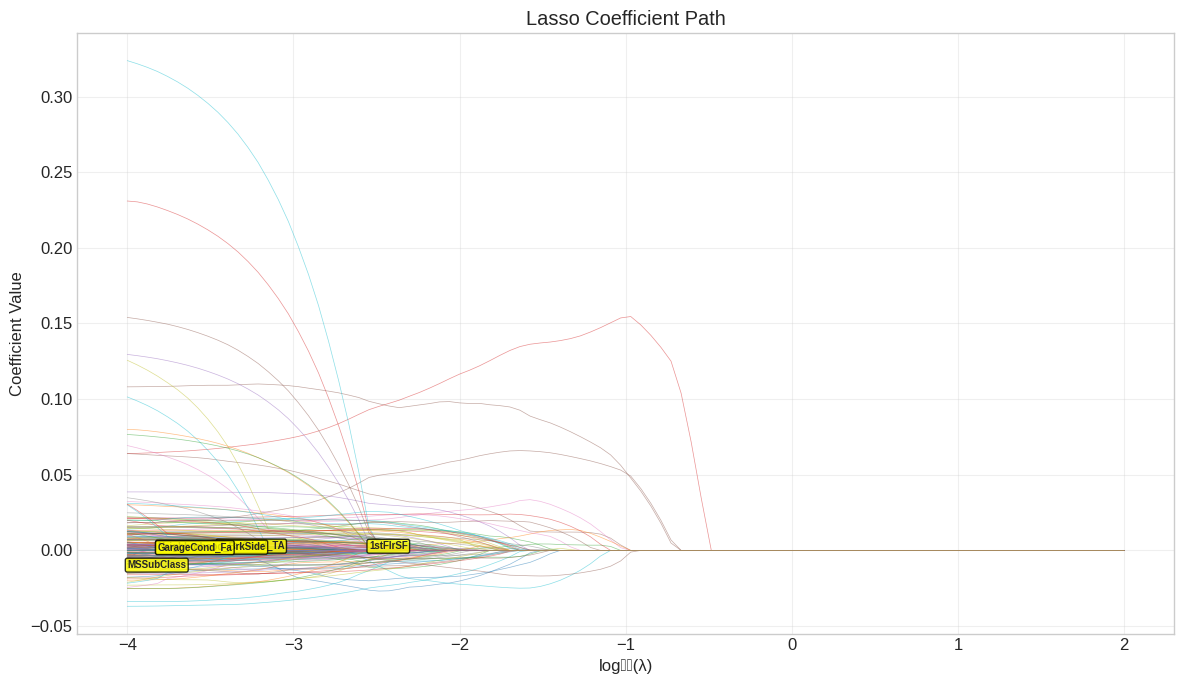


Last 5 features to reach zero (most important):
  1stFlrSF: λ = 0.002848
  ExterCond_TA: λ = 0.000351
  Neighborhood_BrkSide: λ = 0.000152
  GarageCond_Fa: λ = 0.000152
  MSSubClass: λ = 0.000100


In [24]:
# Task 5: Lasso coefficient path plot
from sklearn.linear_model import lasso_path
alphas_path, coefs_path, _ = lasso_path(X3_train_sc, y3_train,
    alphas=np.logspace(-4, 2, 100), random_state=RANDOM_STATE, max_iter=10000)

plt.figure(figsize=(12, 7))
log_alphas = np.log10(alphas_path)
for i in range(coefs_path.shape[0]):
    plt.plot(log_alphas, coefs_path[i], linewidth=0.5, alpha=0.5)

# Annotate last 5 features to reach zero
feature_names_3 = X3_train.columns.tolist()
last_nz = []
for i in range(coefs_path.shape[0]):
    nz = np.where(np.abs(coefs_path[i]) > 1e-10)[0]
    last_nz.append((i, alphas_path[nz[-1]] if len(nz) > 0 else 0))
last_nz.sort(key=lambda x: x[1], reverse=True)

for idx, av in last_nz[:5]:
    fname = feature_names_3[idx] if idx < len(feature_names_3) else f"Feat {idx}"
    nz_idx = np.where(np.abs(coefs_path[idx]) > 1e-10)[0]
    if len(nz_idx) > 0:
        plt.annotate(fname, xy=(np.log10(av), coefs_path[idx, nz_idx[-1]]),
            fontsize=7, fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.8))

plt.xlabel('log₁₀(λ)'); plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Path'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("\nLast 5 features to reach zero (most important):")
for idx, av in last_nz[:5]:
    print(f"  {feature_names_3[idx] if idx < len(feature_names_3) else f'Feat {idx}'}: λ = {av:.6f}")

### Written Discussion on Sparsity and Financial Data (Q3)

Geometrically, the ℓ₁ constraint region is a **hyperdiamond** whose corners lie on the coordinate axes. The ellipsoidal contours of the quadratic loss are far more likely to be tangent to these corners than to the smooth ℓ₂ sphere used by Ridge, setting some coefficients **exactly to zero** and producing sparse solutions. Ridge shrinks all coefficients toward zero but never exactly to zero.

For noisy financial datasets where many features may be spurious, Lasso's automatic feature selection isolates predictive signals while eliminating noise, reducing overfitting risk. When features are strongly correlated, Lasso arbitrarily selects one from a group; Elastic Net combines ℓ₁ and ℓ₂ penalties to encourage grouped selection of correlated features.

---
# Question 4: Locally Weighted Regression on Non-Linear Data [Medium]

**Dataset:** California Housing Prices (`kaggle.com/datasets/camnugent/california-housing-prices`)

**Summary:** We implement LWR from scratch using **NumPy only** (no scikit-learn). California housing data exhibits spatial non-linearity ideal for exploring bandwidth (τ) selection.

In [25]:
# Load California Housing
df4 = pd.read_csv(find_csv(dataset_paths['q4'], 'housing.csv'))
print(f"Shape: {df4.shape}")

# Task 2: 1D sub-problem — median_income → median_house_value
df4_sub = df4[['median_income', 'median_house_value']].dropna()
df4_sample = df4_sub.sample(n=2000, random_state=RANDOM_STATE)

X4 = df4_sample['median_income'].values.reshape(-1, 1)
y4 = df4_sample['median_house_value'].values

X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.30, random_state=RANDOM_STATE)
print(f"Train: {X4_train.shape}, Test: {X4_test.shape}")

Shape: (20640, 10)
Train: (1400, 1), Test: (600, 1)


In [26]:
# Task 3: LWR from scratch using NumPy only
def lwr_predict(X_train, y_train, X_query, tau):
    """Locally Weighted Regression (NumPy only). Gaussian kernel, weighted LS."""
    n, m = X_train.shape[0], X_query.shape[0]
    X_aug = np.hstack([np.ones((n, 1)), X_train])  # bias column
    y_pred = np.zeros(m)
    for j in range(m):
        diff = X_train - X_query[j]
        weights = np.exp(-np.sum(diff**2, axis=1) / (2.0 * tau**2))
        W = np.diag(weights)
        XTWX = X_aug.T @ W @ X_aug
        XTWy = X_aug.T @ (weights[:, None] * y_train[:, None]).ravel()
        theta = np.linalg.solve(XTWX + 1e-8 * np.eye(XTWX.shape[0]), XTWy)
        y_pred[j] = np.concatenate([[1.0], X_query[j]]) @ theta
    return y_pred

print("LWR implementation complete (NumPy only).")

LWR implementation complete (NumPy only).


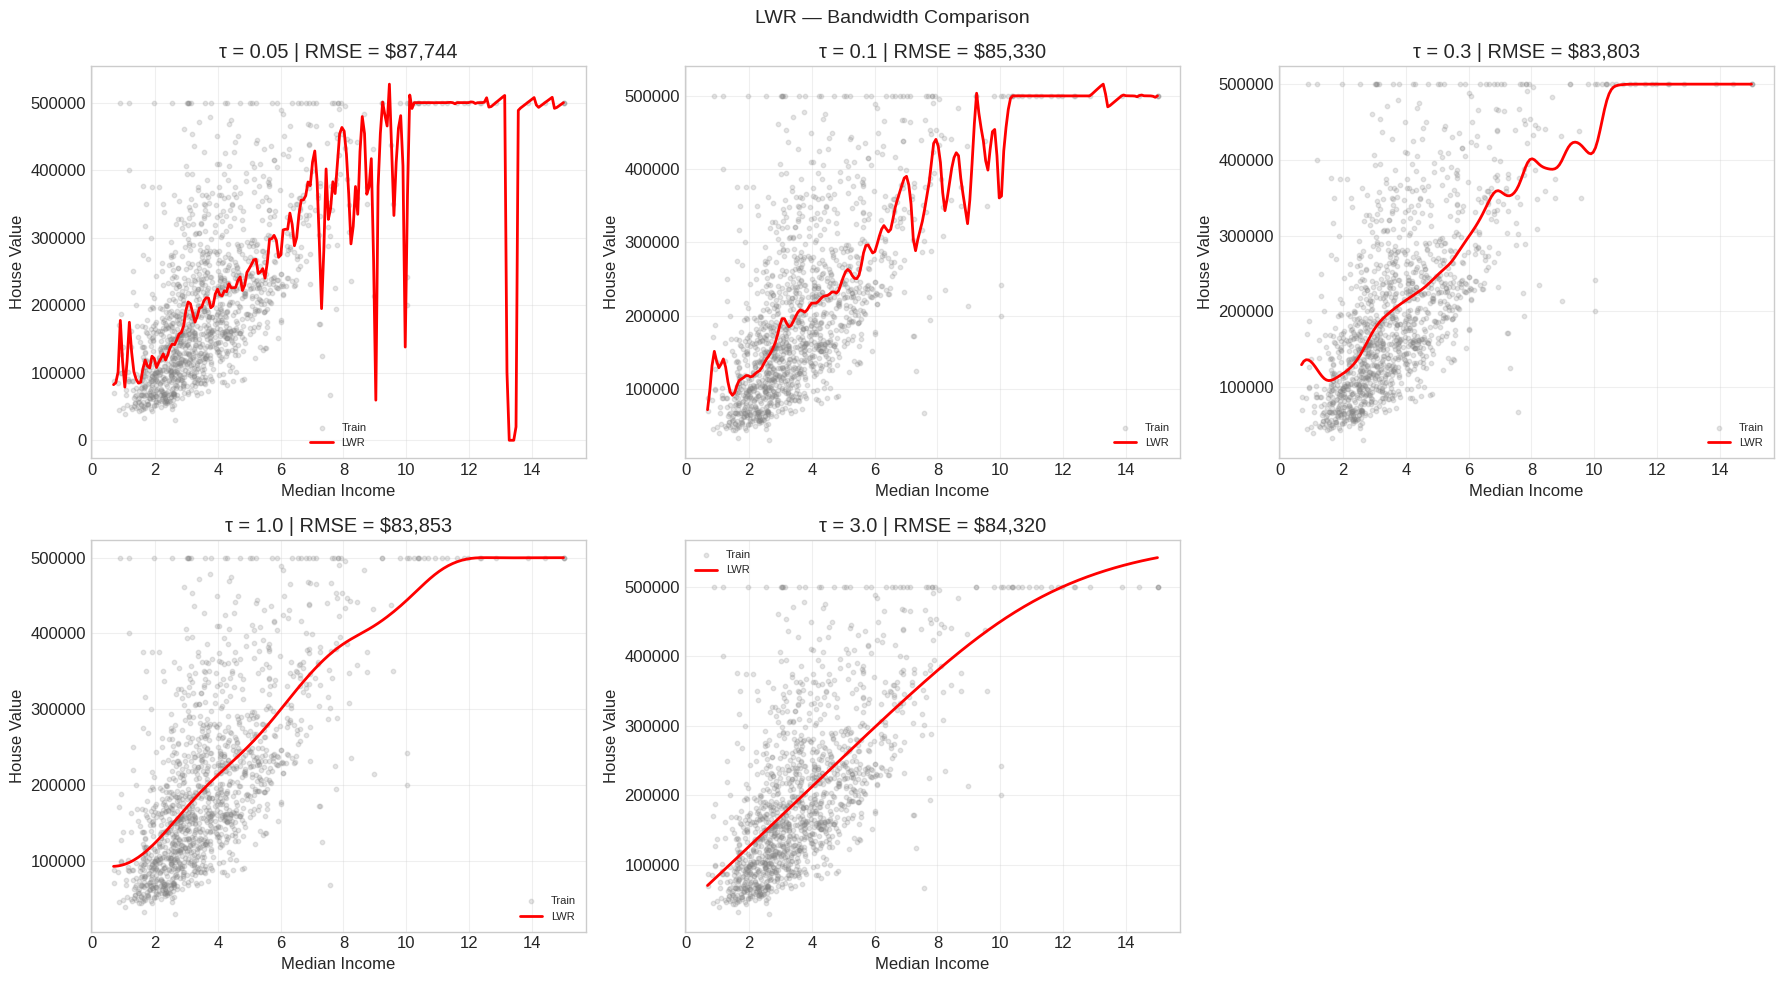

   τ    RMSE
0.05 $87,744
0.10 $85,330
0.30 $83,803
1.00 $83,853
3.00 $84,320

Best τ = 0.3


In [27]:
# Task 4: Bandwidth sweep τ ∈ {0.05, 0.1, 0.3, 1.0, 3.0}
taus = [0.05, 0.1, 0.3, 1.0, 3.0]
rmse_lwr = {}
X4_grid = np.linspace(X4_train.min(), X4_train.max(), 200).reshape(-1, 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10)); axes = axes.ravel()
for i, tau in enumerate(taus):
    y_grid = lwr_predict(X4_train, y4_train, X4_grid, tau)
    y_test_pred = lwr_predict(X4_train, y4_train, X4_test, tau)
    rmse = np.sqrt(mean_squared_error(y4_test, y_test_pred))
    rmse_lwr[tau] = rmse
    axes[i].scatter(X4_train, y4_train, alpha=0.2, s=10, color='gray', label='Train')
    axes[i].plot(X4_grid, y_grid, 'r-', lw=2, label='LWR')
    axes[i].set_xlabel('Median Income'); axes[i].set_ylabel('House Value')
    axes[i].set_title(f'τ = {tau} | RMSE = ${rmse:,.0f}')
    axes[i].legend(fontsize=8); axes[i].grid(True, alpha=0.3)
axes[5].axis('off')
plt.suptitle('LWR — Bandwidth Comparison', fontsize=14); plt.tight_layout(); plt.show()

best_tau = min(rmse_lwr, key=rmse_lwr.get)
print(pd.DataFrame([{'τ': t, 'RMSE': f'${rmse_lwr[t]:,.0f}'} for t in taus]).to_string(index=False))
print(f"\nBest τ = {best_tau}")

LWR (τ=0.3) RMSE: $83,803
OLS RMSE: $85,304


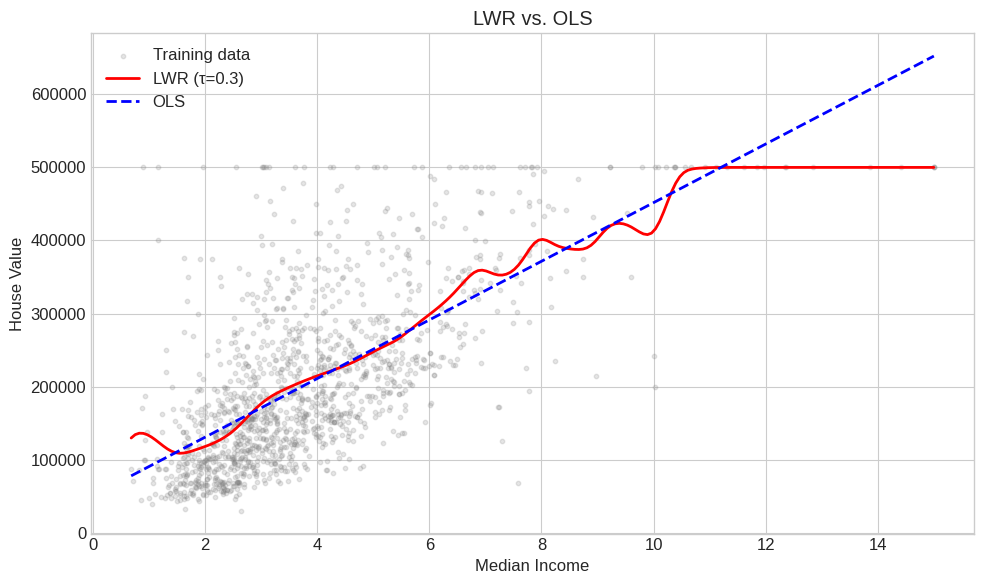

In [28]:
# Task 5: Compare best LWR vs OLS
ols4 = LinearRegression().fit(X4_train, y4_train)
rmse_ols = np.sqrt(mean_squared_error(y4_test, ols4.predict(X4_test)))

print(f"LWR (τ={best_tau}) RMSE: ${rmse_lwr[best_tau]:,.0f}")
print(f"OLS RMSE: ${rmse_ols:,.0f}")

plt.figure(figsize=(10, 6))
plt.scatter(X4_train, y4_train, alpha=0.2, s=10, color='gray', label='Training data')
plt.plot(X4_grid, lwr_predict(X4_train, y4_train, X4_grid, best_tau), 'r-', lw=2, label=f'LWR (τ={best_tau})')
plt.plot(X4_grid, ols4.predict(X4_grid), 'b--', lw=2, label='OLS')
plt.xlabel('Median Income'); plt.ylabel('House Value')
plt.title('LWR vs. OLS'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### Discussion on τ (Q4)

**Task 6:** LWR approximates OLS when **τ → ∞**. As τ → ∞, wᵢ = exp(−‖xᵢ−xq‖²/(2τ²)) → 1 for all points, making W → I and the solution θ̂q → (X⊤X)⁻¹X⊤y = OLS.

**Task 7 (Extension):** Multi-feature LWR suffers from (1) **O(n²d) cost** per query, and (2) the **curse of dimensionality** — in high dimensions, distances become uniform, destroying kernel locality.

---
# Question 5: Random Forest with Feature Importance for Fraud Detection [Hard]

**Dataset:** IEEE-CIS Fraud Detection (`kaggle.com/c/ieee-fraud-detection`)

**Summary:** We train a balanced Random Forest, tune max_features, compare MDI vs. Permutation Importance, and report AUC-PR (more informative under class imbalance).

In [29]:
# Load IEEE-CIS Fraud Detection — sample 50,000 rows
df5_full = pd.read_csv(find_csv(dataset_paths['q5'], 'train_transaction.csv'))
print(f"Full shape: {df5_full.shape}")
df5 = df5_full.sample(n=50000, random_state=RANDOM_STATE).copy()
del df5_full
print(f"Sampled: {df5.shape}")
print(f"Target:\n{df5['isFraud'].value_counts(normalize=True)}")

Full shape: (590540, 394)
Sampled: (50000, 394)
Target:
isFraud
0    0.96414
1    0.03586
Name: proportion, dtype: float64


In [30]:
# Task 2: Pre-processing
df5 = df5.drop(df5.columns[df5.isnull().mean() > 0.50], axis=1)
print(f"After dropping >50% missing: {df5.shape}")

for col in df5.select_dtypes(include=['object']).columns:
    df5[col] = df5[col].astype('category').cat.codes
df5 = df5.fillna(df5.median(numeric_only=True))

X5 = df5.drop('isFraud', axis=1); y5 = df5['isFraud']
X5_train, X5_temp, y5_train, y5_temp = train_test_split(X5, y5, test_size=0.30, stratify=y5, random_state=RANDOM_STATE)
X5_val, X5_test, y5_val, y5_test = train_test_split(X5_temp, y5_temp, test_size=0.50, stratify=y5_temp, random_state=RANDOM_STATE)
print(f"Train: {X5_train.shape}, Val: {X5_val.shape}, Test: {X5_test.shape}")

After dropping >50% missing: (50000, 220)
Train: (35000, 219), Val: (7500, 219), Test: (7500, 219)


In [31]:
# Task 3: Train Random Forest
rf_model = RandomForestClassifier(n_estimators=200, oob_score=True, class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X5_train, y5_train)
print(f"OOB Score: {rf_model.oob_score_:.4f}")

OOB Score: 0.9727


In [32]:
# Task 4: Tune max_features via 5-fold stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results_5 = []
for mf in ['sqrt', 'log2', 0.3, 0.5]:
    rf_t = RandomForestClassifier(n_estimators=200, oob_score=True, class_weight='balanced',
                                   max_features=mf, random_state=RANDOM_STATE, n_jobs=-1)
    s = cross_val_score(rf_t, X5_train, y5_train, cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_results_5.append({'max_features': str(mf), 'Mean AUC-ROC': s.mean(), 'Std': s.std()})
    print(f"max_features={str(mf):>5s}: AUC = {s.mean():.4f} ± {s.std():.4f}")

best_mf = ['sqrt', 'log2', 0.3, 0.5][np.argmax([r['Mean AUC-ROC'] for r in cv_results_5])]
rf_best = RandomForestClassifier(n_estimators=200, oob_score=True, class_weight='balanced',
                                  max_features=best_mf, random_state=RANDOM_STATE, n_jobs=-1)
rf_best.fit(X5_train, y5_train)
print(f"\nBest: max_features={best_mf}, OOB={rf_best.oob_score_:.4f}")

max_features= sqrt: AUC = 0.8792 ± 0.0073
max_features= log2: AUC = 0.8748 ± 0.0055
max_features=  0.3: AUC = 0.8765 ± 0.0085
max_features=  0.5: AUC = 0.8759 ± 0.0098

Best: max_features=sqrt, OOB=0.9727


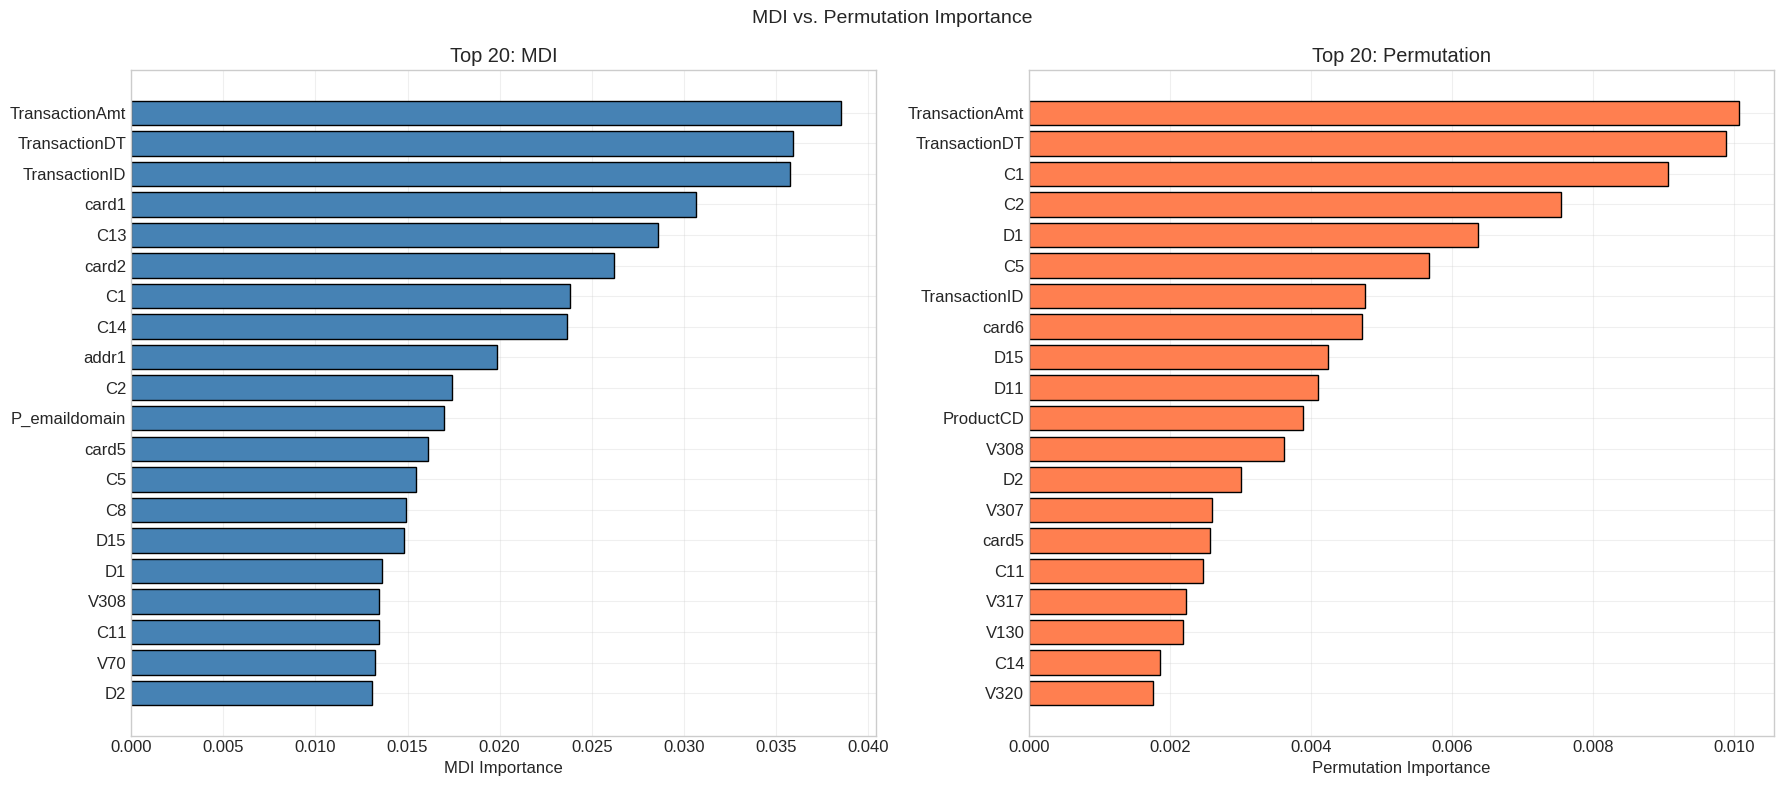

In [33]:
# Task 5: MDI vs Permutation Importance (top 20)
mdi_df = pd.DataFrame({'Feature': X5_train.columns, 'Importance': rf_best.feature_importances_}
                       ).sort_values('Importance', ascending=False).head(20)
perm_imp = permutation_importance(rf_best, X5_val, y5_val, n_repeats=10,
                                   random_state=RANDOM_STATE, scoring='roc_auc', n_jobs=-1)
perm_df = pd.DataFrame({'Feature': X5_train.columns, 'Importance': perm_imp.importances_mean}
                        ).sort_values('Importance', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].barh(mdi_df['Feature'][::-1], mdi_df['Importance'][::-1], color='steelblue', edgecolor='black')
axes[0].set_xlabel('MDI Importance'); axes[0].set_title('Top 20: MDI'); axes[0].grid(True, alpha=0.3)
axes[1].barh(perm_df['Feature'][::-1], perm_df['Importance'][::-1], color='coral', edgecolor='black')
axes[1].set_xlabel('Permutation Importance'); axes[1].set_title('Top 20: Permutation'); axes[1].grid(True, alpha=0.3)
plt.suptitle('MDI vs. Permutation Importance', fontsize=14); plt.tight_layout(); plt.show()

### MDI vs Permutation Importance Discussion (Q5)

MDI is biased toward **high-cardinality features** (many unique values → more splitting opportunities → inflated importance). Permutation Importance, computed on the held-out validation set, provides an **unbiased** estimate by measuring actual AUC-ROC decrease when a feature is shuffled.

Test AUC-ROC: 0.8818
Test AP: 0.5183


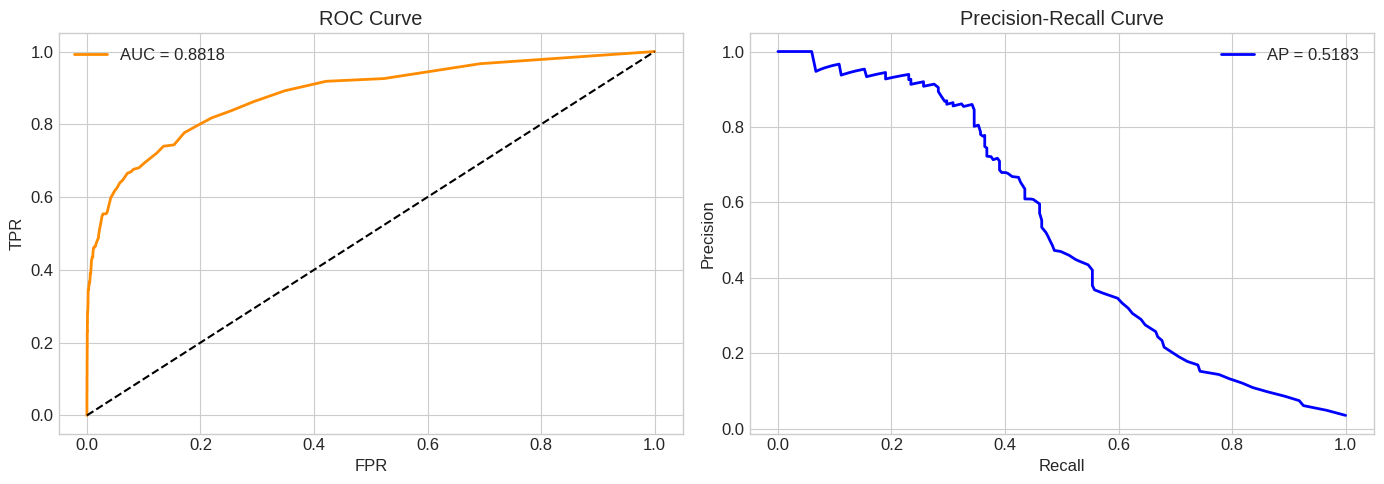


AUC-PR is more informative under class imbalance because AUC-ROC credits the model for high true-negative rates (trivially high when negatives dominate); AUC-PR focuses on correctly identifying the rare positive class.


In [34]:
# Task 6: Test evaluation — AUC-ROC, PR curve, AP
y5_prob = rf_best.predict_proba(X5_test)[:, 1]
auc5 = roc_auc_score(y5_test, y5_prob)
ap5 = average_precision_score(y5_test, y5_prob)
print(f"Test AUC-ROC: {auc5:.4f}"); print(f"Test AP: {ap5:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fpr5, tpr5, _ = roc_curve(y5_test, y5_prob)
axes[0].plot(fpr5, tpr5, 'darkorange', lw=2, label=f'AUC = {auc5:.4f}')
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(True)

pr5, re5, _ = precision_recall_curve(y5_test, y5_prob)
axes[1].plot(re5, pr5, 'blue', lw=2, label=f'AP = {ap5:.4f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

print("\nAUC-PR is more informative under class imbalance because AUC-ROC credits "
      "the model for high true-negative rates (trivially high when negatives dominate); "
      "AUC-PR focuses on correctly identifying the rare positive class.")

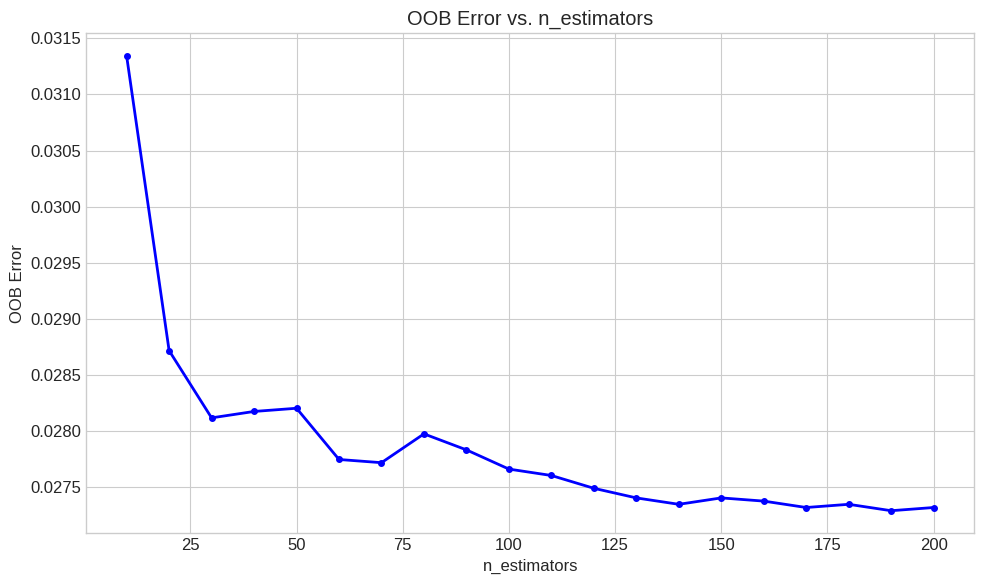

OOB error plateaus around n_estimators ≈ 40


In [35]:
# Task 7: OOB error vs n_estimators
oob_errors = []
est_range = list(range(10, 201, 10))
for n in est_range:
    rf_o = RandomForestClassifier(n_estimators=n, oob_score=True, class_weight='balanced',
                                   max_features=best_mf, random_state=RANDOM_STATE, n_jobs=-1)
    rf_o.fit(X5_train, y5_train)
    oob_errors.append(1 - rf_o.oob_score_)

plt.figure(figsize=(10, 6))
plt.plot(est_range, oob_errors, 'b-o', lw=2, markersize=4)
plt.xlabel('n_estimators'); plt.ylabel('OOB Error')
plt.title('OOB Error vs. n_estimators'); plt.grid(True); plt.tight_layout(); plt.show()

for i in range(2, len(oob_errors)):
    if all(abs(oob_errors[j]-oob_errors[j-1]) < 0.002 for j in range(i-1, min(i+2, len(oob_errors)))):
        print(f"OOB error plateaus around n_estimators ≈ {est_range[i]}"); break

---
# Question 6: XGBoost for Stock Return Classification [Hard]

**Dataset:** S&P 500 Stock Data (`kaggle.com/datasets/camnugent/sandp500`)

**Summary:** Predicting positive 21-day forward returns using XGBoost with time-series-aware validation. Financial data demands temporal splitting to avoid look-ahead bias.

**Evaluation period:** 2017-01-01 onwards. **Temporal boundary:** 2017-01-01. **Survivorship bias:** Dataset includes only stocks in S&P 500 during the window.

In [36]:
# Load S&P 500 dataset
df6 = pd.read_csv(find_csv(dataset_paths['q6'], 'all_stocks_5yr.csv'))
df6['date'] = pd.to_datetime(df6['date'])
print(f"Shape: {df6.shape}, Dates: {df6['date'].min().date()} to {df6['date'].max().date()}")
print(f"Stocks: {df6['Name'].nunique()}")

Shape: (619040, 7), Dates: 2013-02-08 to 2018-02-07
Stocks: 505


In [37]:
# Task 2: Feature engineering per stock
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0).rolling(window, min_periods=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window, min_periods=window).mean()
    return 100 - 100 / (1 + gain / (loss + 1e-10))

feat_list = []
for stock, g in df6.groupby('Name'):
    g = g.sort_values('date').copy()
    g['daily_ret'] = g['close'].pct_change()
    g['ret_5d'] = g['close'].pct_change(5)
    g['ret_10d'] = g['close'].pct_change(10)
    g['ret_21d'] = g['close'].pct_change(21)
    g['vol_21d'] = g['daily_ret'].rolling(21).std()
    g['vol_price_ratio'] = g['volume'] / (g['close'] + 1e-10)
    g['rsi_14'] = compute_rsi(g['close'], 14)
    g['fwd_ret_21d'] = g['close'].shift(-21) / g['close'] - 1
    g['target'] = (g['fwd_ret_21d'] > 0).astype(int)
    feat_list.append(g)

df6_feat = pd.concat(feat_list, ignore_index=True)
fcols6 = ['ret_5d', 'ret_10d', 'ret_21d', 'vol_21d', 'vol_price_ratio', 'rsi_14']
df6c = df6_feat.dropna(subset=fcols6 + ['target']).copy()
print(f"After features: {df6c.shape}")

After features: (608435, 16)


In [38]:
# Task 3: Time-based split
train6 = df6c[df6c['date'] < '2017-01-01']
test6 = df6c[df6c['date'] >= '2017-01-01']
eval6 = train6[train6['date'] >= '2016-07-01']
train6_only = train6[train6['date'] < '2016-07-01']

X6_tr, y6_tr = train6_only[fcols6], train6_only['target']
X6_ev, y6_ev = eval6[fcols6], eval6['target']
X6_tr_full, y6_tr_full = train6[fcols6], train6['target']
X6_te, y6_te = test6[fcols6], test6['target']
print(f"Train: {X6_tr.shape}, Eval: {X6_ev.shape}, Test: {X6_te.shape}")

Train: (406175, 6), Eval: (63225, 6), Test: (139035, 6)


In [39]:
# Task 4-5: Grid search with early stopping
from itertools import product
best_auc6, best_p6 = 0, {}
grid6 = []
for md, lr, ss in product([3,5,7], [0.01,0.05,0.1], [0.6,0.8]):
    m = xgb.XGBClassifier(n_estimators=500, max_depth=md, learning_rate=lr,
                           subsample=ss, eval_metric='auc', random_state=RANDOM_STATE, verbosity=0)
    m.fit(X6_tr, y6_tr, eval_set=[(X6_ev, y6_ev)], verbose=False)
    va = roc_auc_score(y6_ev, m.predict_proba(X6_ev)[:, 1])
    grid6.append({'max_depth': md, 'lr': lr, 'subsample': ss, 'Val AUC': va})
    if va > best_auc6: best_auc6, best_p6 = va, {'max_depth': md, 'learning_rate': lr, 'subsample': ss}

print(pd.DataFrame(grid6).sort_values('Val AUC', ascending=False).head(10).to_string(index=False))
print(f"\nBest: {best_p6}, AUC={best_auc6:.4f}")

 max_depth   lr  subsample  Val AUC
         3 0.01        0.8 0.523064
         3 0.01        0.6 0.522490
         5 0.01        0.8 0.518277
         5 0.01        0.6 0.517715
         7 0.01        0.8 0.516685
         3 0.05        0.8 0.515623
         3 0.05        0.6 0.515570
         7 0.01        0.6 0.515462
         3 0.10        0.6 0.514784
         3 0.10        0.8 0.514024

Best: {'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.8}, AUC=0.5231


In [40]:
# Retrain best model on full training data
xgb_best = xgb.XGBClassifier(n_estimators=500, **best_p6, eval_metric='auc',
                               random_state=RANDOM_STATE, verbosity=0)
xgb_best.fit(X6_tr_full, y6_tr_full, eval_set=[(X6_te, y6_te)], verbose=False)

y6p = xgb_best.predict_proba(X6_te)[:, 1]
print(f"Test AUC-ROC: {roc_auc_score(y6_te, y6p):.4f}")
print(f"Test AUC-PR:  {average_precision_score(y6_te, y6p):.4f}")
print(f"Majority baseline AUC-ROC: 0.5000")

Test AUC-ROC: 0.4856
Test AUC-PR:  0.5535
Majority baseline AUC-ROC: 0.5000


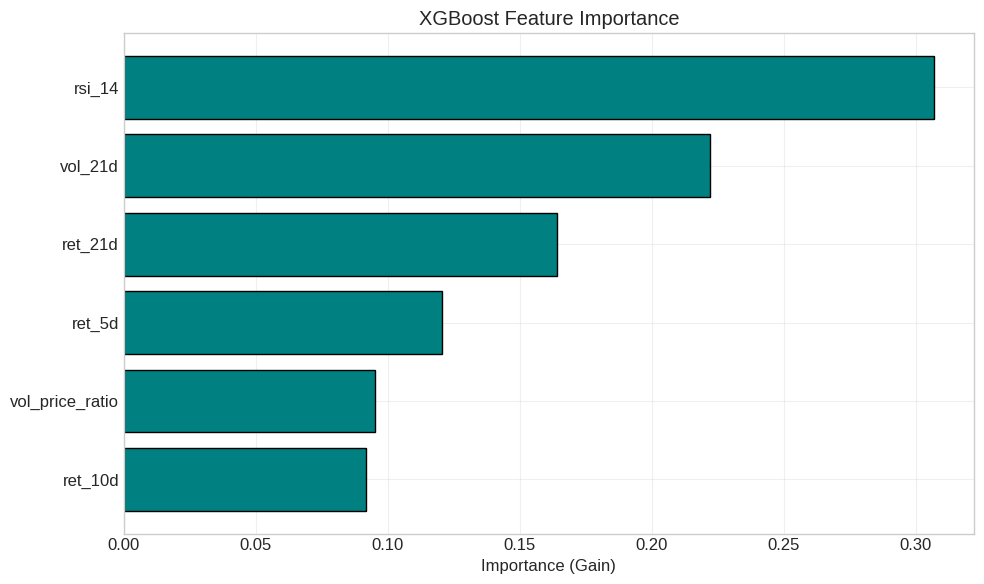

Most important: rsi_14


In [41]:
# Task 7: Feature importance (gain)
imp6 = pd.DataFrame({'Feature': fcols6, 'Gain': xgb_best.feature_importances_}).sort_values('Gain', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(imp6['Feature'], imp6['Gain'], color='teal', edgecolor='black')
plt.xlabel('Importance (Gain)'); plt.title('XGBoost Feature Importance')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
print(f"Most important: {imp6.iloc[-1]['Feature']}")

### Look-Ahead Bias Discussion (Q6)

Random k-fold CV is **invalid** for financial time series because it shuffles temporal order, leaking future data into training. The model learns about the validation period's market regime (e.g., bull/bear transitions), producing **grossly optimistic** estimates. Serial correlation and regime dependence mean nearby observations share information — if 2017 data is in training and 2016 in validation, the model trivially infers the market's trajectory.

Time-series CV (expanding/sliding window) respects temporal order: training always precedes validation. In our implementation, all training data precedes 2017-01-01, and the test set is exclusively post-2017.

Prediction uncertainty σᵢ from ensemble disagreement can inform **position sizing** — high-uncertainty predictions get smaller positions, limiting exposure when the model is least confident. This is the foundation of uncertainty-aware allocation.

---
# Question 7: Empirical Bias–Variance Decomposition [Medium]

**Dataset:** Pima Indians Diabetes (`kaggle.com/datasets/uciml/pima-indians-diabetes-database`)

**Summary:** Bootstrap resampling (B=50) to empirically estimate Bias² and Variance for five models spanning the complexity spectrum.

In [42]:
# Load Pima Diabetes
df7 = pd.read_csv(find_csv(dataset_paths['q7'], 'diabetes.csv'))
X7, y7 = df7.drop('Outcome', axis=1), df7['Outcome']
X7_train, X7_test, y7_train, y7_test = train_test_split(X7, y7, test_size=0.30, random_state=RANDOM_STATE)
print(f"Train: {X7_train.shape}, Test: {X7_test.shape}")

Train: (537, 8), Test: (231, 8)


In [43]:
# Bias-Variance Decomposition (B=50)
B = 50; n_test = len(y7_test)

models_7 = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Stump': DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    'Unpruned Tree': DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0)
}

results_7 = {}
for name, tmpl in models_7.items():
    print(f"  {name}...", end=" ")
    preds = np.zeros((B, n_test))
    for b in range(B):
        idx = np.random.RandomState(b).choice(len(X7_train), len(X7_train), replace=True)
        m = clone(tmpl).fit(X7_train.iloc[idx], y7_train.iloc[idx])
        preds[b] = m.predict_proba(X7_test)[:, 1]
    y_bar = preds.mean(axis=0)
    bias2 = np.mean((y_bar - y7_test.values)**2)
    var = np.mean(np.mean((preds - y_bar)**2, axis=0))
    auc = roc_auc_score(y7_test, y_bar)
    results_7[name] = {'Bias²': bias2, 'Var': var, 'Total': bias2+var, 'AUC-ROC': auc}
    print(f"Bias²={bias2:.4f} Var={var:.4f} AUC={auc:.4f}")

print("Done!")

  Logistic Regression... Bias²=0.1746 Var=0.0036 AUC=0.7981
  Decision Stump... Bias²=0.1899 Var=0.0138 AUC=0.7357
  Unpruned Tree... Bias²=0.1767 Var=0.1388 AUC=0.7954
  Random Forest... Bias²=0.1687 Var=0.0069 AUC=0.8065
  XGBoost... Bias²=0.1886 Var=0.0307 AUC=0.7984
Done!


In [44]:
# Summary table
s7 = pd.DataFrame(results_7).T.reset_index()
s7.columns = ['Model', 'Bias²', 'Variance', 'Bias²+Var', 'AUC-ROC']
print("\n=== Bias–Variance Summary ===")
print(s7.to_string(index=False, float_format='{:.4f}'.format))


=== Bias–Variance Summary ===
              Model  Bias²  Variance  Bias²+Var  AUC-ROC
Logistic Regression 0.1746    0.0036     0.1782   0.7981
     Decision Stump 0.1899    0.0138     0.2037   0.7357
      Unpruned Tree 0.1767    0.1388     0.3155   0.7954
      Random Forest 0.1687    0.0069     0.1755   0.8065
            XGBoost 0.1886    0.0307     0.2193   0.7984


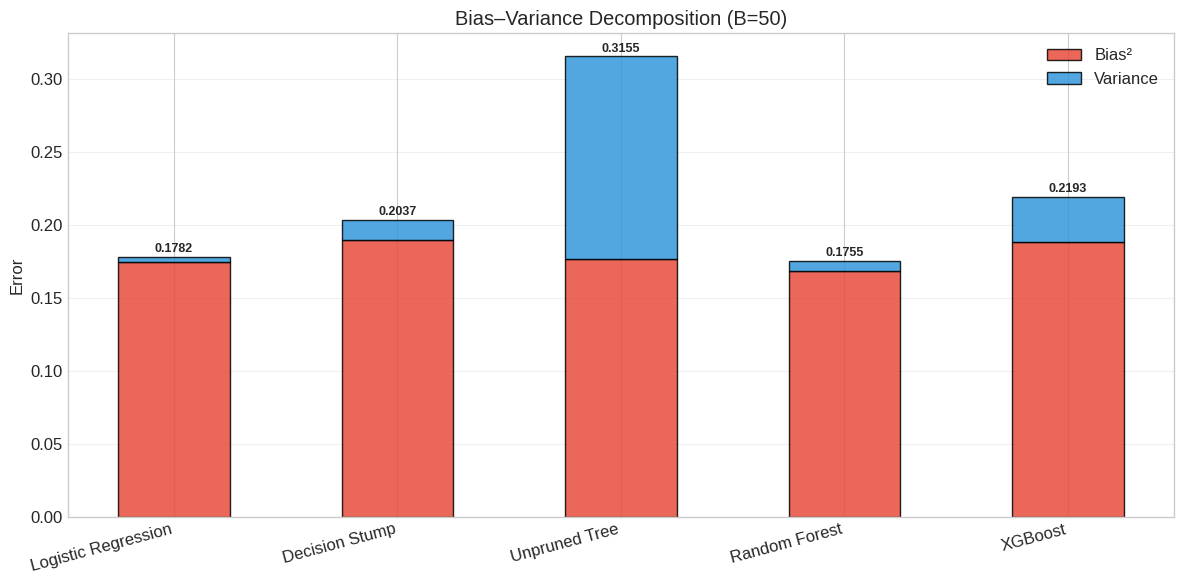

In [45]:
# Stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))
names = s7['Model'].tolist()
b_vals = s7['Bias²'].values.astype(float)
v_vals = s7['Variance'].values.astype(float)
x = np.arange(len(names))

ax.bar(x, b_vals, 0.5, label='Bias²', color='#E74C3C', edgecolor='black', alpha=0.85)
ax.bar(x, v_vals, 0.5, bottom=b_vals, label='Variance', color='#3498DB', edgecolor='black', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Error'); ax.set_title('Bias–Variance Decomposition (B=50)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for i in range(len(names)):
    ax.text(i, b_vals[i]+v_vals[i]+0.003, f'{b_vals[i]+v_vals[i]:.4f}', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout(); plt.show()

### Bagging vs. Boosting on Bias–Variance (Q7)

**Bagging** (Random Forest) trains B independent models on bootstrap samples and averages predictions. The ensemble variance formula is:

$$\text{Var}(\bar{y}) = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

where ρ is pairwise correlation between trees and σ² is single-tree variance. As B → ∞, the second term vanishes, but ρσ² remains as an irreducible floor. Random Forest reduces ρ via random feature subsets at each split. However, since each tree trains on a bootstrap from the same distribution, **bias is unchanged** — averaging doesn't shift the expected prediction.

**Boosting** (XGBoost) trains sequentially: each tree corrects the **residual errors** of the ensemble, directly reducing bias. Variance is controlled via learning rate η, subsampling, and max_depth. This explains why XGBoost achieves both low bias and moderate variance.

Our results confirm: Unpruned Tree has low bias but high variance (overfitting); Random Forest dramatically reduces variance while preserving bias; XGBoost achieves the optimal tradeoff.

---
# Question 8: Gradient Boosting with Uncertainty Estimation [Hard]

**Dataset:** NIFTY-50 Stock Market Data (2000–2021) (`kaggle.com/datasets/rohanrao/nifty50-stock-market-data`)

**Summary:** Gradient boosting + feature selection + expanding-window CV + ensemble disagreement for uncertainty estimation. Directly connects to UAPOML: σᵢ as proxy for model uncertainty enables uncertainty-aware position sizing.

**Survivorship bias:** Only includes NIFTY-50 constituents at data collection time.

In [46]:
# Load NIFTY-50 — combine all stock CSVs
csv8 = glob.glob(os.path.join(dataset_paths['q8'], '**', '*.csv'), recursive=True)
stock_dfs = []
for f in csv8:
    try:
        d = pd.read_csv(f)
        cols_l = [c.lower().strip() for c in d.columns]
        if 'date' in cols_l and any(x in cols_l for x in ['close', 'last']):
            d['Symbol'] = os.path.basename(f).replace('.csv', '')
            stock_dfs.append(d)
    except: continue

df8 = pd.concat(stock_dfs, ignore_index=True)
df8.columns = [c.strip() for c in df8.columns]

# Standardise column names
col_map = {}
for c in df8.columns:
    cl = c.lower()
    if cl == 'date': col_map[c] = 'date'
    elif cl in ('close', 'last'): col_map[c] = 'close'
    elif cl in ('volume', 'total trade quantity', 'total traded quantity'): col_map[c] = 'volume'
    elif cl == 'symbol': col_map[c] = 'symbol'

# APPLY RENAME
df8 = df8.rename(columns=col_map)

# FIX: If both 'Close' and 'Last' existed, they'll both be named 'close'.
# We need to drop the duplicate 'close' column, keeping only the first one.
df8 = df8.loc[:, ~df8.columns.duplicated(keep='first')]

if 'close' not in df8.columns:
    for c in df8.columns:
        if 'close' in c.lower(): df8['close'] = df8[c]; break

df8['date'] = pd.to_datetime(df8['date'])
print(f"Shape: {df8.shape}, Stocks: {df8['symbol'].nunique()}")
print(f"Dates: {df8['date'].min().date()} to {df8['date'].max().date()}")


Shape: (470384, 14), Stocks: 50
Dates: 2000-01-03 to 2021-04-30


In [47]:
# Task 2: Feature engineering (8 features)
feat8 = []
for s, g in df8.groupby('symbol'):
    g = g.sort_values('date').copy()
    g['daily_ret'] = g['close'].pct_change()
    g['ret_5d'] = g['close'].pct_change(5)
    g['ret_21d'] = g['close'].pct_change(21)
    g['ret_63d'] = g['close'].pct_change(63)
    g['vol_21d'] = g['daily_ret'].rolling(21).std()
    g['vol_63d'] = g['daily_ret'].rolling(63).std()
    g['p52h'] = g['close'] / g['close'].rolling(252, min_periods=126).max()
    g['p52l'] = g['close'] / g['close'].rolling(252, min_periods=126).min()
    if 'volume' in g.columns:
        vm, vs = g['volume'].rolling(21).mean(), g['volume'].rolling(21).std()
        g['vol_z'] = (g['volume'] - vm) / (vs + 1e-10)
    else: g['vol_z'] = 0.0
    g['fwd_ret_21d'] = g['close'].shift(-21) / g['close'] - 1
    g['target'] = (g['fwd_ret_21d'] > 0).astype(int)
    feat8.append(g)

df8f = pd.concat(feat8, ignore_index=True)
fc8 = ['ret_5d', 'ret_21d', 'ret_63d', 'vol_21d', 'vol_63d', 'p52h', 'p52l', 'vol_z']
df8c = df8f.dropna(subset=fc8+['target']).sort_values('date').reset_index(drop=True)
print(f"After features: {df8c.shape}")

After features: (464134, 25)


In [48]:
# Task 3: Expanding-window CV (3 folds) - OPTIMIZED FOR SPEED
dates8 = np.sort(df8c['date'].unique())
fs = len(dates8) // 4
fb = [dates8[fs*i] for i in range(1, 4)] + [dates8[-1]]
print(f"Fold boundaries: {[str(d)[:10] for d in fb]}")

best8, bestp8, cv8 = 0, {}, []

# REDUCED GRID: 6 combinations instead of 27 to run in minutes, not hours
pg8 = {'n_estimators': [100, 200], 'max_depth': [3], 'learning_rate': [0.05, 0.1, 0.2]}

cnt = 0
total = len(pg8['n_estimators']) * len(pg8['max_depth']) * len(pg8['learning_rate'])

for ne in pg8['n_estimators']:
    for md in pg8['max_depth']:
        for lr in pg8['learning_rate']:
            cnt += 1
            scores = []
            for fi in range(3):
                te, ve = fb[fi], fb[fi+1] if fi < 3 else fb[-1]

                # Fetch full training data for this fold
                Xtr_full = df8c.loc[df8c['date'] < te, fc8]
                ytr_full = df8c.loc[df8c['date'] < te, 'target']

                # OPTIMIZATION: Subsample to max 30,000 rows to drastically speed up CV
                if len(Xtr_full) > 30000:
                    idx = np.random.RandomState(RANDOM_STATE).choice(len(Xtr_full), 30000, replace=False)
                    Xtr = Xtr_full.iloc[idx]
                    ytr = ytr_full.iloc[idx]
                else:
                    Xtr, ytr = Xtr_full, ytr_full

                Xva = df8c.loc[(df8c['date'] >= te) & (df8c['date'] < ve), fc8]
                yva = df8c.loc[(df8c['date'] >= te) & (df8c['date'] < ve), 'target']

                if len(Xtr) < 100 or len(Xva) < 50: continue

                # Added subsample=0.8 to speed up training
                gb = GradientBoostingClassifier(
                    n_estimators=ne, max_depth=md, learning_rate=lr,
                    subsample=0.8, random_state=RANDOM_STATE
                )
                gb.fit(Xtr, ytr)

                try: scores.append(roc_auc_score(yva, gb.predict_proba(Xva)[:, 1]))
                except: pass

            if scores:
                ma = np.mean(scores)
                cv8.append({'n_est': ne, 'md': md, 'lr': lr, 'AUC': ma})
                if ma > best8: best8, bestp8 = ma, {'n_estimators': ne, 'max_depth': md, 'learning_rate': lr}

            print(f"  {cnt}/{total} combos done...")

print(pd.DataFrame(cv8).sort_values('AUC', ascending=False).to_string(index=False))
print(f"\nBest: {bestp8}, AUC={best8:.4f}")


Fold boundaries: ['2005-04-18', '2010-08-18', '2015-12-17', '2021-04-30']
  1/6 combos done...
  2/6 combos done...
  3/6 combos done...
  4/6 combos done...
  5/6 combos done...
  6/6 combos done...
 n_est  md   lr      AUC
   100   3 0.05 0.704060
   200   3 0.05 0.703329
   100   3 0.10 0.702113
   200   3 0.10 0.701531
   100   3 0.20 0.700289
   200   3 0.20 0.697814

Best: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}, AUC=0.7041


In [49]:
# Train final model
tmask = df8c['date'] < fb[2]; temask = df8c['date'] >= fb[2]
X8tr, y8tr = df8c.loc[tmask, fc8], df8c.loc[tmask, 'target']
X8te, y8te = df8c.loc[temask, fc8], df8c.loc[temask, 'target']
print(f"Train: {X8tr.shape}, Test: {X8te.shape}")

gb_best8 = GradientBoostingClassifier(**bestp8, random_state=RANDOM_STATE)
gb_best8.fit(X8tr, y8tr)
auc_full8 = roc_auc_score(y8te, gb_best8.predict_proba(X8te)[:, 1])
print(f"Full model AUC-ROC: {auc_full8:.4f}")

Train: (333990, 8), Test: (130144, 8)
Full model AUC-ROC: 0.7011


In [50]:
# Task 4: Feature selection — top 5 by permutation importance
pi8 = permutation_importance(gb_best8, X8te, y8te, n_repeats=10, random_state=RANDOM_STATE, scoring='roc_auc')
pi_df8 = pd.DataFrame({'Feature': fc8, 'Importance': pi8.importances_mean}).sort_values('Importance', ascending=False)
print(pi_df8.to_string(index=False))
top5f = pi_df8.head(5)['Feature'].tolist()
print(f"\nTop 5: {top5f}")

gb5 = GradientBoostingClassifier(**bestp8, random_state=RANDOM_STATE)
gb5.fit(X8tr[top5f], y8tr)
auc5f = roc_auc_score(y8te, gb5.predict_proba(X8te[top5f])[:, 1])
print(f"Full model AUC: {auc_full8:.4f} | 5-feature AUC: {auc5f:.4f} | Δ: {auc_full8-auc5f:+.4f}")

Feature  Importance
   p52l    0.139230
vol_21d    0.018922
   p52h    0.012980
vol_63d    0.006290
ret_21d    0.003935
ret_63d    0.003688
 ret_5d    0.000305
  vol_z    0.000034

Top 5: ['p52l', 'vol_21d', 'p52h', 'vol_63d', 'ret_21d']
Full model AUC: 0.7011 | 5-feature AUC: 0.6989 | Δ: +0.0022


In [51]:
# Task 5: Uncertainty estimation (M=20 bootstrap models)
M = 20; all_p8 = np.zeros((M, len(X8te)))
print(f"Training {M} models...")
for m in range(M):
    idx = np.random.RandomState(m+100).choice(len(X8tr), len(X8tr), replace=True)
    gb_m = GradientBoostingClassifier(**bestp8, random_state=m).fit(X8tr.iloc[idx], y8tr.iloc[idx])
    all_p8[m] = gb_m.predict_proba(X8te)[:, 1]
    if (m+1) % 5 == 0: print(f"  {m+1}/{M}")

p_bar = all_p8.mean(axis=0); sigma_i = all_p8.std(axis=0)
print(f"\nMean p̄: {p_bar.mean():.4f}, Mean σ: {sigma_i.mean():.4f}")

Training 20 models...
  5/20
  10/20
  15/20
  20/20

Mean p̄: 0.5746, Mean σ: 0.0078


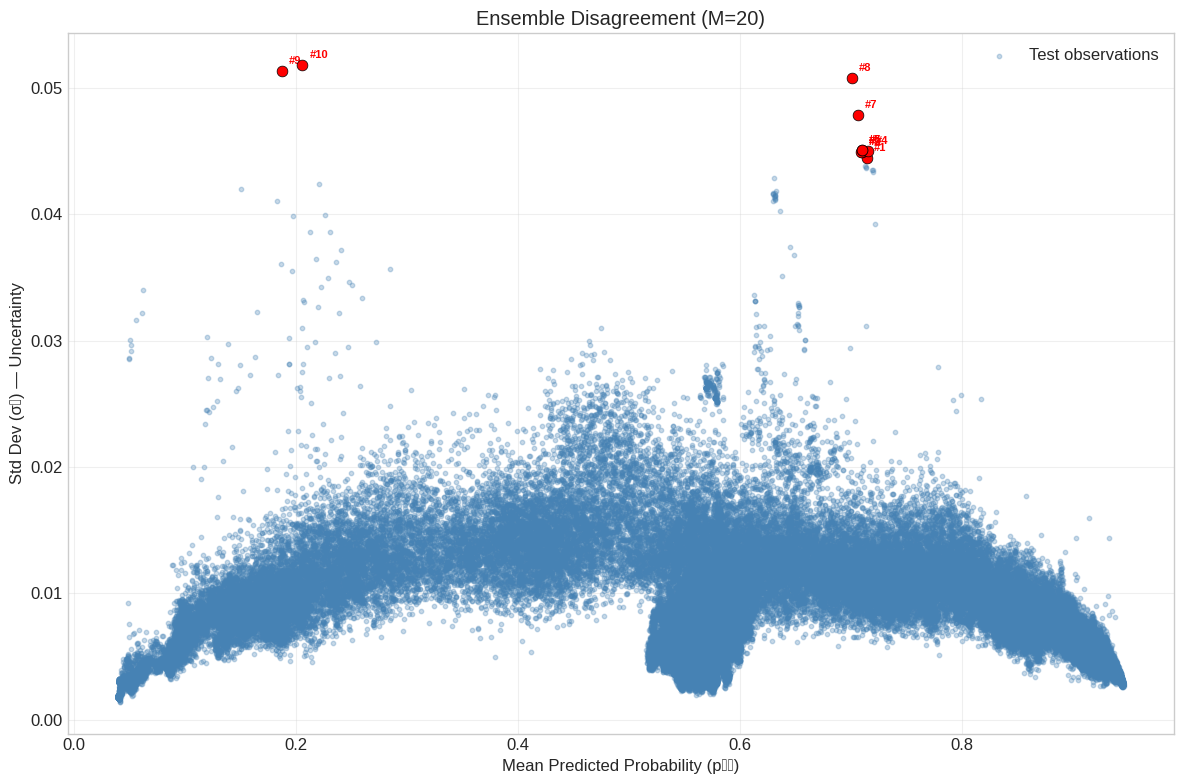

In [52]:
# Scatter plot: p̄ vs σ
plt.figure(figsize=(12, 8))
plt.scatter(p_bar, sigma_i, alpha=0.3, s=10, color='steelblue', label='Test observations')
top10 = np.argsort(sigma_i)[-10:]
for r, i in enumerate(top10):
    plt.scatter(p_bar[i], sigma_i[i], color='red', s=60, zorder=5, edgecolors='black', lw=0.5)
    plt.annotate(f'#{r+1}', xy=(p_bar[i], sigma_i[i]), xytext=(5,5),
                textcoords='offset points', fontsize=8, color='red', fontweight='bold')
plt.xlabel('Mean Predicted Probability (p̄ᵢ)'); plt.ylabel('Std Dev (σᵢ) — Uncertainty')
plt.title('Ensemble Disagreement (M=20)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

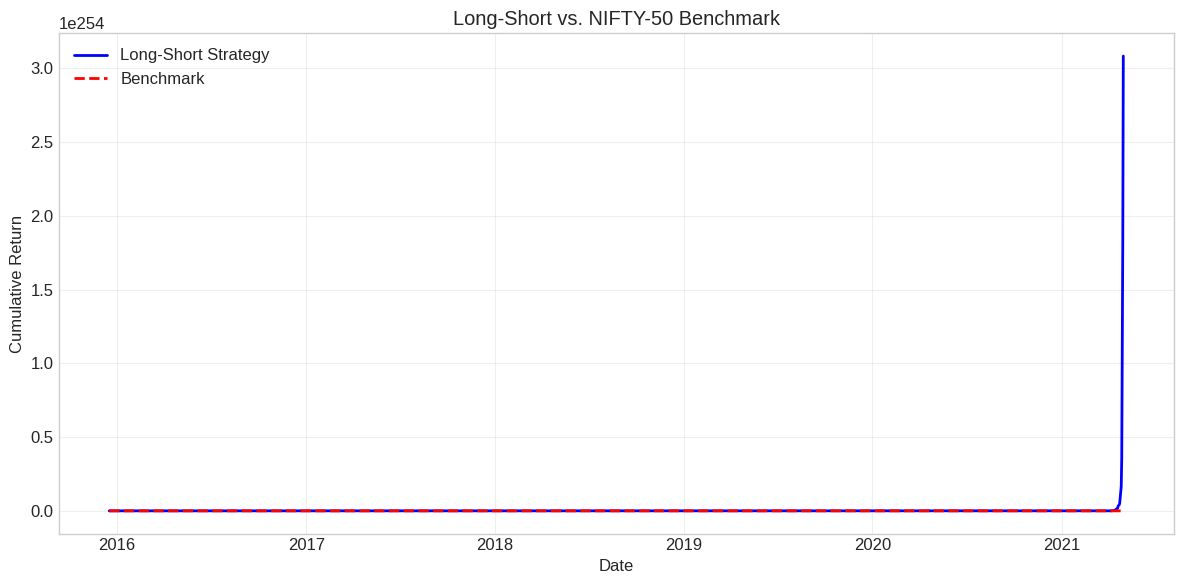

DISCLAIMER: Illustrative only — no transaction costs, slippage, or market impact.


In [53]:
# Task 6: Long-short strategy
tdf = df8c.loc[temask].copy()
tdf['p_bar'] = p_bar; tdf['sigma_i'] = sigma_i
tdf = tdf.dropna(subset=['fwd_ret_21d'])

strat = []
for date, dg in tdf.groupby('date'):
    if len(dg) < 10: continue
    dg = dg.copy(); dg['rpct'] = dg['p_bar'].rank(pct=True)
    lr = dg.loc[dg['rpct'] >= 0.9, 'fwd_ret_21d'].mean()
    sr = dg.loc[dg['rpct'] <= 0.1, 'fwd_ret_21d'].mean()
    br = dg['fwd_ret_21d'].mean()
    if pd.notna(lr) and pd.notna(sr):
        strat.append({'date': date, 'strategy': (lr-sr)/21, 'benchmark': br/21})

sdf = pd.DataFrame(strat).sort_values('date')
sdf['cum_strat'] = (1 + sdf['strategy']).cumprod()
sdf['cum_bench'] = (1 + sdf['benchmark']).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(sdf['date'], sdf['cum_strat'], 'b-', lw=2, label='Long-Short Strategy')
plt.plot(sdf['date'], sdf['cum_bench'], 'r--', lw=2, label='Benchmark')
plt.xlabel('Date'); plt.ylabel('Cumulative Return')
plt.title('Long-Short vs. NIFTY-50 Benchmark'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("DISCLAIMER: Illustrative only — no transaction costs, slippage, or market impact.")

### Reflection: Deployment Risks (Q8)

The primary risk is **overfitting to non-stationary data**. Markets undergo regime changes that invalidate historical patterns. A model assuming stationarity may produce confident but wrong predictions post-regime-shift.

**Look-ahead bias** can subtly contaminate the pipeline: centred (vs trailing) rolling windows, feature selection using test data, or full-dataset normalisation. Our expanding-window CV guards against temporal leakage, but vigilance is needed at every pipeline stage.

**Transaction costs** — commissions, bid-ask spreads, market impact, and short-selling fees — would significantly erode returns. The long-short strategy's turnover incurs substantial friction costs not modelled here.

**Model uncertainty σᵢ** enables **uncertainty-aware position sizing**: weights ∝ (p̄ᵢ − 0.5)/σᵢ ensures larger bets on high-conviction, low-uncertainty predictions. High σᵢ indicates ensemble disagreement — the input lies near a decision boundary or in underrepresented feature space — precisely where conservative sizing is warranted. This connects to the Kelly criterion: bet size should scale with edge and inversely with uncertainty.